# Análise exploratória e preparação dos dados — Brasileirão Série A (2020–2023)

**Disciplina:** Inteligência Artificial II

**Objetivo desta etapa:** conhecer, validar e preparar o arquivo `partidas_20_23.csv` para, em uma etapa futura, treinar um modelo que preveja uma de três classes: **vitória do mandante** (`home_win`), **empate** (`draw`) ou **vitória do visitante** (`away_win`).

Neste notebook **não há treinamento de modelo**. Toda a lógica reutilizável está em `src/data_analysis.py`; o notebook a chama passo a passo, mostra tabelas e gráficos e explica as decisões. Os números citados em texto são calculados pelo código, não digitados.

**Como executar de novo:** `Run All` neste notebook, ou `python src/data_analysis.py` na raiz do projeto. O CSV original nunca é alterado.

## 0. Configuração

In [1]:
import sys
from pathlib import Path

# Localiza a raiz do projeto de forma relativa, sem caminhos absolutos da máquina.
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "data_analysis.py").exists())
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import data_analysis as da

RANDOM_STATE = da.RANDOM_STATE  # semente fixa (42)
np.random.seed(RANDOM_STATE)
da.configurar_log()
da._preparar_estilo()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

print("Raiz do projeto:", RAIZ.name)
print("CSV original   :", da.CSV_ORIGINAL.relative_to(RAIZ))
print("Semente        :", RANDOM_STATE)

Raiz do projeto: trabalhoIA2
CSV original   : partidas_20_23.csv
Semente        : 42


## 1. Carregamento inicial

O arquivo é lido de duas formas:

* **leitura padrão do Pandas**, para ver tipos e valores nulos como o Pandas os enxerga;
* **leitura como texto** (`dtype=str`, sem converter nada em ausente), para não perder marcadores como `No data`.

Uma coluna sem nulos **não** está necessariamente correta: a ausência pode estar escrita como texto ou como lista vazia, por isso ela é procurada explicitamente.

In [2]:
bruto = da.carregar_dados_brutos()
bruto_texto = da.carregar_dados_brutos(como_texto=True)
carga = da.resumo_carga_inicial(bruto, bruto_texto)

print(f"Linhas: {carga['linhas']} | Colunas: {carga['colunas']}")
print(f"Memória aproximada: {da.num(carga['memoria_mb'], 2)} MB")
print(f"Equipes diferentes: {carga['n_equipes']}")
print(f"Linhas duplicadas: {carga['duplicadas']}")
print(f"Período: {carga['data_min']:%d/%m/%Y} a {carga['data_max']:%d/%m/%Y}")
print("Colunas:", carga["nomes_colunas"])

Linhas: 1520 | Colunas: 17
Memória aproximada: 2,30 MB
Equipes diferentes: 26
Linhas duplicadas: 0
Período: 08/08/2020 a 06/12/2023
Colunas: ['home_team', 'away_team', 'home_team_score', 'away_team_score', 'game_date', 'stadium', 'public', 'ref', 'yellow_cards_home', 'red_cards_home', 'gols_home', 'yellow_cards_away', 'red_cards_away', 'gols_away', 'sec_card_home', 'sec_card_away', 'link']


In [3]:
carga["tipos"]

,tipo
home_team,str
away_team,str
home_team_score,int64
away_team_score,int64
game_date,str
stadium,str
public,str
ref,str
yellow_cards_home,str
red_cards_home,str


**Cinco primeiras linhas** (as colunas de listas JSON aparecem como texto):

In [4]:
carga["cabeca"]

,home_team,away_team,home_team_score,away_team_score,game_date,stadium,public,ref,yellow_cards_home,red_cards_home,gols_home,yellow_cards_away,red_cards_away,gols_away,sec_card_home,sec_card_away,link
0,CR Vasco da Gama,Goiás EC,3,2,25 de fevereiro de 2021 21:30,São Januário,No data,Leandro Pedro Vuaden,"[{""player"": ""Leonardo de Matos Cruz"", ""minute""...",[],"[{""player"": ""Germ\u00e1n Ezequiel Cano"", ""minu...","[{""player"": ""Miguel Ferreira Damasceno"", ""minu...",[],"[{""player"": ""Jos\u00e9 Fernando Viana de Santa...",[],[],https://optaplayerstats.statsperform.com/pt_BR...
1,São Paulo FC,CR Flamengo,2,1,25 de fevereiro de 2021 21:30,Morumbi,No data,Rodolpho Toski Marques,"[{""player"": ""Danilo das Neves Pinheiro"", ""minu...",[],"[{""player"": ""Luciano da Rocha Neves"", ""minute""...","[{""player"": ""Gabriel Barbosa Almeida"", ""minute...",[],"[{""player"": ""Bruno Henrique Pinto"", ""minute"": ...",[],[],https://optaplayerstats.statsperform.com/pt_BR...
2,SC Internacional,SC Corinthians Paulista,0,0,25 de fevereiro de 2021 21:30,Beira-Rio,No data,Wilton Pereira Sampaio,[],[],[],"[{""player"": ""V\u00edctor Danilo Cantillo Jim\u...",[],[],[],[],https://optaplayerstats.statsperform.com/pt_BR...
3,Fluminense FC,Fortaleza EC,2,0,25 de fevereiro de 2021 21:30,Estádio Jornalista Mário Filho (Maracanã),No data,Anderson Daronco,[],[],"[{""player"": ""Frederico Chaves Guedes"", ""minute...",[],[],[],[],[],https://optaplayerstats.statsperform.com/pt_BR...
4,Ceará SC,Botafogo FR,2,1,25 de fevereiro de 2021 21:30,Castelão,No data,Raphael Claus,"[{""player"": ""Gabriel Santos Cordeiro Lacerda"",...",[],"[{""player"": ""Pedro Henrique Naressi Machado"", ...",[],[],"[{""player"": ""Matheus Barcelos da Silva"", ""minu...","[{""player"": ""William Klaus"", ""minute"": ""81'""}]",[],https://optaplayerstats.statsperform.com/pt_BR...


**Cinco últimas linhas:**

In [5]:
carga["cauda"]

,home_team,away_team,home_team_score,away_team_score,game_date,stadium,public,ref,yellow_cards_home,red_cards_home,gols_home,yellow_cards_away,red_cards_away,gols_away,sec_card_home,sec_card_away,link
1515,Red Bull Bragantino,EC Bahia,2,1,15 de abril de 2023 18:30,Nabizão,3.368,Maguielson Lima Barbosa,"[{""player"": ""Jadsom Meemyas de Oliveira da Sil...",[],"[{""player"": ""Bruno Gon\u00e7alves de Jesus"", ""...","[{""player"": ""Francisco V\u00edtor Silva Costa""...",[],"[{""player"": ""Everaldo Stum"", ""minute"": ""45'"", ...",[],[],https://optaplayerstats.statsperform.com/pt_BR...
1516,Botafogo FR,São Paulo FC,2,1,15 de abril de 2023 18:30,Estádio Nilton Santos,11.708,Ramon Abatti,"[{""player"": ""Leonel Di Pl\u00e1cido"", ""minute""...",[],"[{""player"": ""Francisco das Chagas Soares dos S...","[{""player"": ""Jhegson Sebasti\u00e1n M\u00e9nde...",[],"[{""player"": ""Jonathan Calleri"", ""minute"": ""15'...",[],[],https://optaplayerstats.statsperform.com/pt_BR...
1517,Club Athletico Paranaense,Goiás EC,2,0,15 de abril de 2023 18:30,Arena da Baixada,15.329,Rafael Rodrigo Klein,"[{""player"": ""Pedro Henrique Ribeiro Gon\u00e7a...",[],"[{""player"": ""Pedro Henrique Ribeiro Gon\u00e7a...","[{""player"": ""Sidimar Fernando Cigolini"", ""minu...",[],[],[],[],https://optaplayerstats.statsperform.com/pt_BR...
1518,SE Palmeiras,Cuiabá EC,2,1,15 de abril de 2023 16:00,Allianz Parque,35.835,Paulo Cesar Zanovelli da Silva,"[{""player"": ""Jos\u00e9 Manuel Alberto L\u00f3p...","[{""player"": ""Abel Ferreira"", ""minute"": ""45+1'""}]","[{""player"": ""Endrick Felipe Moreira de Sousa"",...","[{""player"": ""Deyverson Brum Silva Acosta"", ""mi...",[],"[{""player"": ""Raniele Almeida Melo"", ""minute"": ...",[],"[{""player"": ""Filipe Augusto Carvalho Souza"", ""...",https://optaplayerstats.statsperform.com/pt_BR...
1519,América FC (Minas Gerais),Fluminense FC,0,3,15 de abril de 2023 16:00,Estádio Raimundo Sampaio,6.653,Braulio da Silva Machado,"[{""player"": ""Iago Justen Maidana Martins"", ""mi...",[],[],"[{""player"": ""Vitor Mendes Alves"", ""minute"": ""4...",[],"[{""player"": ""Germ\u00e1n Ezequiel Cano"", ""minu...",[],[],https://optaplayerstats.statsperform.com/pt_BR...


**Valores ausentes na leitura padrão** e **partidas por temporada** (temporada lida do `link`; veja a seção 3):

In [6]:
display(carga["ausentes_leitura_padrao"].T)
display(carga["partidas_por_temporada"].T)

,home_team,away_team,home_team_score,away_team_score,game_date,stadium,public,ref,yellow_cards_home,red_cards_home,gols_home,yellow_cards_away,red_cards_away,gols_away,sec_card_home,sec_card_away,link
ausentes,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,2020,2021,2022,2023
partidas,380,380,380,380


### Ausência "disfarçada": texto vazio, `No data` e listas vazias

A leitura padrão não acusa nenhum nulo. A tabela abaixo mostra onde a informação realmente falta.

In [7]:
marcadores = da.verificar_marcadores_ausentes(bruto_texto)
marcadores[marcadores["total_sem_informacao"] > 0]

,texto_vazio,no_data,lista_vazia,total_sem_informacao
coluna,,,,
public,0,613,0,613
yellow_cards_home,0,0,113,113
red_cards_home,0,0,1392,1392
gols_home,0,0,367,367
yellow_cards_away,0,0,120,120
red_cards_away,0,0,1377,1377
gols_away,0,0,543,543
sec_card_home,0,0,1457,1457
sec_card_away,0,0,1439,1439


In [8]:
display(Markdown(
    f"Somente a coluna **`public`** tem o marcador `No data` ({int(marcadores.loc['public', 'no_data'])} linhas). "
    "As listas vazias nas colunas de eventos são, em geral, ausência legítima de eventos: por exemplo, "
    f"`gols_home` está vazia em {int(marcadores.loc['gols_home', 'lista_vazia'])} partidas, "
    f"e {int((bruto['home_team_score'] == 0).sum())} mandantes marcaram zero gols. Essa coincidência é conferida na seção 5.1."
))

Somente a coluna **`public`** tem o marcador `No data` (613 linhas). As listas vazias nas colunas de eventos são, em geral, ausência legítima de eventos: por exemplo, `gols_home` está vazia em 367 partidas, e 367 mandantes marcaram zero gols. Essa coincidência é conferida na seção 5.1.

## 2. Processamento: datas, temporada, público, listas JSON, alvo e variáveis derivadas

A função `processar_partidas` executa, em ordem, todas as transformações. Antes de rodá-la, cada tratamento é demonstrado abaixo com exemplos, inclusive com entradas inválidas.

### 2.1 Datas em português
`game_date` vem como `25 de fevereiro de 2021 21:30`. O mês é traduzido por dicionário (`MAPA_MESES`), o que não depende do idioma configurado no computador. Entradas fora do padrão viram `NaT` e são contadas, nunca descartadas em silêncio.

In [9]:
teste = pd.Series(["25 de fevereiro de 2021 21:30", "8 de agosto de 2020 16:00",
                   "31 de fevereiro de 2021 10:00",   # data inexistente
                   "5 de marte de 2021 10:00",        # mês desconhecido
                   "2021-02-25"])                     # formato diferente
pd.DataFrame({"texto": teste, "convertido": da.converter_data_ptbr(teste)})

,texto,convertido
0,25 de fevereiro de 2021 21:30,2021-02-25 21:30:00
1,8 de agosto de 2020 16:00,2020-08-08 16:00:00
2,31 de fevereiro de 2021 10:00,NaT
3,5 de marte de 2021 10:00,NaT
4,2021-02-25,NaT


### 2.2 Temporada extraída do `link`
A temporada **não** pode ser o ano da data: partidas da temporada 2020 foram jogadas em 2021. O `link` traz o identificador da competição (`brasileirão-série-a-AAAA`), extraído por expressão regular.

In [10]:
exemplo_link = bruto_texto["link"].iloc[0]
print(exemplo_link)
print("Temporada extraída:", da.extrair_temporada(pd.Series([exemplo_link])).iloc[0])

https://optaplayerstats.statsperform.com/pt_BR/soccer/brasileir%C3%A3o-s%C3%A9rie-a-2020/1ruuku31y4hamxz48qnbvwfoq/match/view/5d9g78zocz08wn1ng2qm0odii
Temporada extraída: 2020


### 2.3 Público
Regras: `12.089` → `12089`; `No data` → ausente (NaN); **nunca** zero. Textos fora desses dois formatos também virariam NaN e seriam contados.

In [11]:
amostra = pd.Series(["12.089", "931", "1.234.567", "No data", "abc"])
convertido, inesperados = da.converter_publico(amostra)
display(pd.DataFrame({"texto": amostra, "publico": convertido}))
print("Formatos inesperados na amostra:", inesperados)

,texto,publico
0,12.089,12089
1,931,931
2,1.234.567,1234567
3,No data,<NA>
4,abc,<NA>


Formatos inesperados na amostra: 1


### 2.4 Listas JSON
`converter_lista_json` recebe o conteúdo da célula, valida que é uma lista, **não usa `eval`** e registra qualquer problema em vez de escondê-lo.

In [12]:
casos = {
    "lista válida": '[{"player": "A", "minute": "17\'"}]',
    "lista vazia": "[]",
    "texto vazio": "",
    "JSON quebrado": '[{"player": ',
    "não é lista": '{"player": "A"}',
    "elemento inválido": '[1, {"player": "B", "minute": "3\'"}]',
}
registro = []
linhas = []
for nome, valor in casos.items():
    resultado = da.converter_lista_json(valor, coluna="teste", indice=nome, registro=registro)
    linhas.append({"caso": nome, "eventos_lidos": len(resultado)})
display(pd.DataFrame(linhas))
print("Problemas sinalizados pela função:")
display(pd.DataFrame(registro)[["linha", "motivo"]])

,caso,eventos_lidos
0,lista válida,1
1,lista vazia,0
2,texto vazio,0
3,JSON quebrado,0
4,não é lista,0
5,elemento inválido,1


Problemas sinalizados pela função:


,linha,motivo
0,texto vazio,texto vazio
1,JSON quebrado,JSON inválido (Expecting value)
2,não é lista,conteúdo não é lista (dict)
3,elemento inválido,elementos que não são objetos


### 2.5 Execução do processamento completo

In [13]:
df, aux = da.processar_partidas(bruto_texto)
print("Base processada:", df.shape)
print("Células JSON problemáticas:", len(aux["inconsistencias_json"]))
print("Datas não interpretadas   :", aux["datas_nao_interpretadas"])
print("Temporadas não extraídas  :", aux["temporadas_nao_extraidas"])
print("Público em formato inesperado:", aux["publico_formato_inesperado"])

[INFO] Processamento concluído: 1520 partidas, 66 colunas.


Base processada: (1520, 66)
Células JSON problemáticas: 0
Datas não interpretadas   : 0
Temporadas não extraídas  : 0
Público em formato inesperado: 0


## 3. Validação das partidas e qualidade dos dados

Cada linha da tabela é uma verificação executada sobre os dados, com a quantidade encontrada e o tratamento adotado.

In [14]:
auditoria = da.auditar_qualidade(bruto_texto, df, aux)
auditoria

,Verificação,Quantidade,Tratamento adotado
0,Linhas completamente duplicadas,0,Nenhum tratamento necessário.
1,Links duplicados,0,Nenhum tratamento necessário; o link identific...
2,"Combinações duplicadas (data, mandante, visita...",0,Nenhum tratamento necessário.
3,Mandante igual ao visitante,0,Nenhum tratamento necessário.
4,Placares negativos,0,Nenhum tratamento necessário.
5,Placares não numéricos,0,Nenhum tratamento necessário.
6,Gols do placar ≠ eventos de gol (mandante ou v...,0,O placar é mantido como fonte principal; diver...
7,Listas JSON inválidas ou de tipo inesperado,0,Conversão segura sem eval; conteúdo inválido v...
8,Temporadas com quantidade de partidas ≠ 380,0,Nenhum tratamento necessário.
9,Temporadas com quantidade de equipes ≠ 20,0,Nenhum tratamento necessário.


### 3.1 Nomes das equipes

In [15]:
nomes = da.verificar_nomes_equipes(bruto_texto)
display(Markdown(
    f"**{len(nomes['nomes'])} nomes distintos.** Com espaços extras: {len(nomes['espacos_extras'])}. "
    f"Variações do mesmo time (sem acento/caixa/pontuação): {len(nomes['variacoes_exatas'])}. "
    f"Pares com similaridade ≥ 0,85: {len(nomes['nomes_parecidos'])}."
))
pd.Series(nomes["nomes"], name="nome oficial na base").to_frame()

**26 nomes distintos.** Com espaços extras: 0. Variações do mesmo time (sem acento/caixa/pontuação): 0. Pares com similaridade ≥ 0,85: 0.

,nome oficial na base
0,América FC (Minas Gerais)
1,Atlético Goianiense
2,Avai FC
3,Botafogo FR
4,CR Flamengo
5,CR Vasco da Gama
6,Ceará SC
7,Chapecoense AF
8,Club Athletico Paranaense
9,Clube Atlético Mineiro


### 3.2 Temporada × ano calendário
Confirma por que a temporada precisa vir do `link`.

In [16]:
pd.crosstab(df["temporada"], df["ano_calendario"], margins=True)

ano_calendario,2020,2021,2022,2023,All
temporada,,,,,
2020,268,112,0,0,380
2021,0,380,0,0,380
2022,0,0,380,0,380
2023,0,0,0,380,380
All,268,492,380,380,1520


In [17]:
fora = int((df["ano_calendario"] != df["temporada"]).sum())
display(Markdown(
    f"**{fora} partidas ({da.pct(fora / len(df))})** foram disputadas em um ano diferente da temporada "
    f"— todas da temporada {', '.join(str(int(t)) for t in df.loc[df['ano_calendario'] != df['temporada'], 'temporada'].unique())}. "
    "Se a temporada fosse deduzida do ano da data, essas partidas seriam atribuídas à temporada errada."
))

**112 partidas (7,4%)** foram disputadas em um ano diferente da temporada — todas da temporada 2020. Se a temporada fosse deduzida do ano da data, essas partidas seriam atribuídas à temporada errada.

## 4. Público ausente

Como o marcador `No data` não diz **por que** o público falta, a análise primeiro descreve **onde** ele falta, e só depois discute possíveis causas.

In [18]:
pub = da.analise_publico_ausente(df)
n_aus = int(df["publico"].isna().sum())
display(Markdown(f"**Público ausente: {n_aus} partidas ({da.pct(n_aus / len(df))}).** Nunca foi preenchido com zero."))
pub["por_temporada"]

**Público ausente: 613 partidas (40,3%).** Nunca foi preenchido com zero.

,partidas,ausentes,percentual
temporada,,,
2020,380,380,100.000
2021,380,218,57.368
2022,380,2,0.526
2023,380,13,3.421


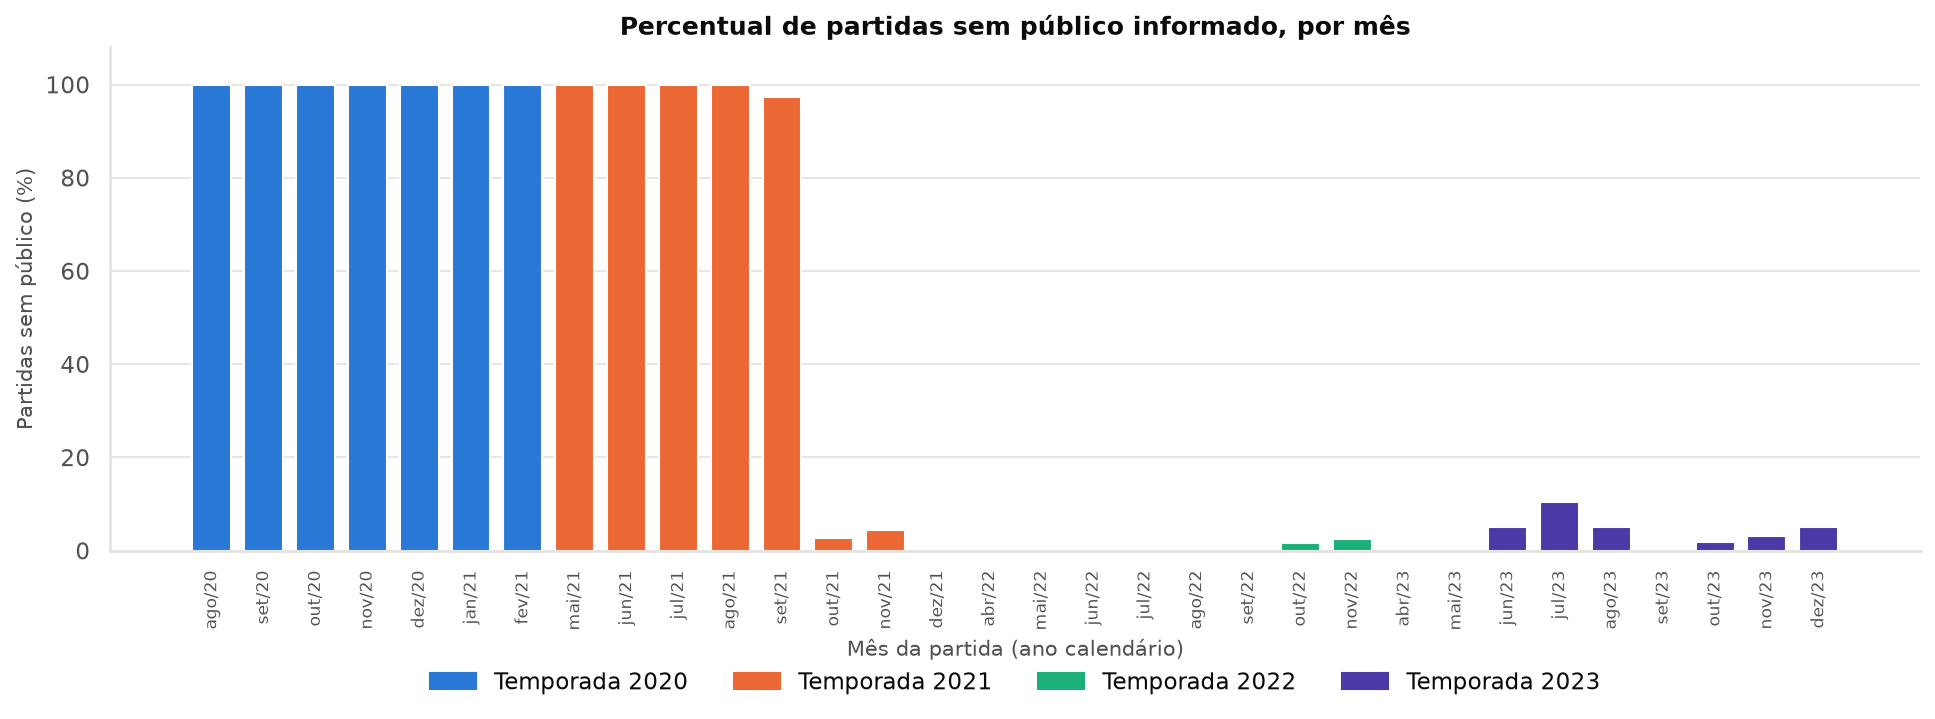

In [19]:
display(Image(filename=str(da.grafico_publico_ausente_mes(df))))

In [20]:
disp = pub["disponiveis_por_temporada"]
prim = pub["primeiro_publico_disponivel"]["primeira_data_com_publico"]
d21 = df[df["temporada"] == 2021]
antes = d21[d21["data_partida"] < prim.loc[2021]]
depois = d21[d21["data_partida"] >= prim.loc[2021]]
display(Markdown(
    f"* **2020:** {int(pub['por_temporada'].loc[2020, 'ausentes'])} de {int(pub['por_temporada'].loc[2020, 'partidas'])} partidas sem público.\n"
    f"* **2021:** a primeira partida com público informado é de {prim.loc[2021]:%d/%m/%Y}. "
    f"Antes dessa data, {int(antes['publico'].notna().sum())} de {len(antes)} partidas têm público; depois, {int(depois['publico'].notna().sum())} de {len(depois)}.\n"
    f"* **2022 e 2023:** apenas {int(pub['por_temporada'].loc[2022, 'ausentes'])} e {int(pub['por_temporada'].loc[2023, 'ausentes'])} partidas sem público."
))

* **2020:** 380 de 380 partidas sem público.
* **2021:** a primeira partida com público informado é de 18/09/2021. Antes dessa data, 0 de 193 partidas têm público; depois, 162 de 187.
* **2022 e 2023:** apenas 2 e 13 partidas sem público.

**Interpretação (com cautela).** A ausência não é aleatória: concentra-se no início do período (2020 e boa parte de 2021) e some quase por completo depois. Esse padrão é **compatível** com partidas sem torcida durante a pandemia, mas os dados, sozinhos, **não permitem distinguir** "portões fechados" de "público não coletado", porque a fonte usa o mesmo marcador nos dois casos. Portanto essa explicação é uma **hipótese** a ser confirmada em fonte externa.

O que os dados permitem afirmar com segurança:

1. a ausência está fortemente associada à temporada (100% em 2020);
2. logo, `publico` não pode entrar no modelo sem tratamento, pois substituí-lo por zero ou pela média criaria informação inexistente e confundiria "público" com "temporada";
3. as médias de público por temporada (seção 8) são calculadas somente com as partidas que têm informação e **não são comparáveis** entre temporadas sem cuidado, já que em 2021 só sobram jogos do fim da temporada.

## 5. Variáveis extraídas das listas JSON

Para mandante e visitante foram criadas as contagens de gols (eventos), amarelos, vermelhos diretos, segundos amarelos, expulsões (`vermelhos_diretos + segundos_amarelos`), pênaltis convertidos e gols contra.

In [21]:
colunas_eventos = [c for c in df.columns if c.endswith(("_mandante", "_visitante"))
                   and c.split("_mandante")[0].split("_visitante")[0] in
                   ("gols_eventos", "amarelos", "vermelhos_diretos", "segundos_amarelos", "expulsoes",
                    "penaltis_convertidos", "gols_contra")]
df[colunas_eventos].describe().T[["count", "mean", "min", "max"]]

,count,mean,min,max
gols_eventos_mandante,1520.000,1.376,0.000,7.000
amarelos_mandante,1520.000,2.393,0.000,8.000
vermelhos_diretos_mandante,1520.000,0.091,0.000,2.000
segundos_amarelos_mandante,1520.000,0.043,0.000,2.000
expulsoes_mandante,1520.000,0.135,0.000,3.000
penaltis_convertidos_mandante,1520.000,0.147,0.000,2.000
gols_contra_mandante,1520.000,0.033,0.000,1.000
gols_eventos_visitante,1520.000,1.016,0.000,6.000
amarelos_visitante,1520.000,2.524,0.000,10.000
vermelhos_diretos_visitante,1520.000,0.105,0.000,3.000


### 5.1 Gols do placar × eventos de gol
O placar registrado é a **fonte principal** do resultado. As listas de eventos apenas são comparadas a ele; nunca o corrigem.

In [22]:
div = da.divergencias_gols(df)
total_eventos = int(df["gols_eventos_mandante"].sum() + df["gols_eventos_visitante"].sum())
total_placar = int(df["total_gols"].sum())
display(Markdown(
    f"**Partidas com divergência entre placar e eventos: {len(div)}.** "
    f"Total de eventos de gol: {total_eventos}; total de gols no placar: {total_placar}."
))
div

**Partidas com divergência entre placar e eventos: 0.** Total de eventos de gol: 3637; total de gols no placar: 3637.

,id_partida,temporada,home_team,away_team,home_team_score,away_team_score,gols_eventos_mandante,gols_eventos_visitante,gols_contra_mandante,gols_contra_visitante


In [23]:
gc_h, gc_v = int(df["gols_contra_mandante"].sum()), int(df["gols_contra_visitante"].sum())
display(Markdown(
    f"Há {gc_h + gc_v} gols contra registrados ({gc_h} na lista do mandante e {gc_v} na do visitante). "
    "Se cada gol contra estivesse listado na equipe do jogador que o cometeu, o total de eventos de uma equipe **não** bateria com o seu placar. "
    "Como bate em todas as partidas, a base lista o gol contra na equipe que recebeu o gol. "
    "Isso é uma inferência a partir da consistência dos números (não é possível confirmar a equipe de cada jogador só com estes dados)."
))

Há 88 gols contra registrados (50 na lista do mandante e 38 na do visitante). Se cada gol contra estivesse listado na equipe do jogador que o cometeu, o total de eventos de uma equipe **não** bateria com o seu placar. Como bate em todas as partidas, a base lista o gol contra na equipe que recebeu o gol. Isso é uma inferência a partir da consistência dos números (não é possível confirmar a equipe de cada jogador só com estes dados).

Possíveis causas de divergência, caso existissem: gols contra registrados na equipe errada, eventos ausentes ou duplicados na coleta, ou placar corrigido depois (por exemplo, por decisão de tribunal). **Nenhuma** dessas situações apareceu neste arquivo.

### 5.2 Plausibilidade dos eventos e dos cartões

In [24]:
ev = da.verificar_eventos(df, aux["listas"])
ev

,quantidade
eventos,11558
minuto_fora_do_formato,0
minuto_acima_de_120,0
jogador_vazio,0
evento_duplicado_na_lista,0
segundos_amarelos,149
segundo_amarelo_jogador_tambem_na_lista_de_amarelos,149
segundo_amarelo_mesmo_jogador_e_minuto_na_lista_de_amarelos,10
mesmo_jogador_em_vermelho_direto_e_segundo_amarelo,0


In [25]:
q = ev["quantidade"]
display(Markdown(
    f"Dos {int(q['segundos_amarelos'])} segundos amarelos, {int(q['segundo_amarelo_jogador_tambem_na_lista_de_amarelos'])} têm o jogador na lista de amarelos "
    "(o primeiro cartão). Em "
    f"{int(q['segundo_amarelo_mesmo_jogador_e_minuto_na_lista_de_amarelos'])} casos o jogador aparece com **o mesmo minuto** nas duas listas, "
    "o que sugere que o segundo amarelo também foi contado como amarelo. Como é raro e não confirmável, `total_amarelos` foi mantido como a soma das listas, sem correção."
))

Dos 149 segundos amarelos, 149 têm o jogador na lista de amarelos (o primeiro cartão). Em 10 casos o jogador aparece com **o mesmo minuto** nas duas listas, o que sugere que o segundo amarelo também foi contado como amarelo. Como é raro e não confirmável, `total_amarelos` foi mantido como a soma das listas, sem correção.

## 6. Variável-alvo e variáveis derivadas da partida

`resultado` é definido **apenas** pelo placar registrado:

| Classe | Código | Significado |
|---|---|---|
| `home_win` | 0 | o mandante marcou mais gols que o visitante |
| `draw` | 1 | as duas equipes marcaram o mesmo número de gols |
| `away_win` | 2 | o visitante marcou mais gols que o mandante |

In [26]:
da.distribuicao_resultados(df)

,classe,significado,codigo,partidas,percentual
0,home_win,Vitória do mandante,0,691,45.461
1,draw,Empate,1,427,28.092
2,away_win,Vitória do visitante,2,402,26.447


> **Atenção — vazamento de dados.** As variáveis abaixo (`total_gols`, `saldo_gols_mandante`, `total_amarelos`, `total_expulsoes`, `teve_expulsao`, `teve_penalti_convertido`, `teve_gol_contra`) descrevem a partida **já concluída**. Servem para análise exploratória. Informações ocorridas **durante a própria partida** — placar, gols, cartões e expulsões — **não podem ser usadas diretamente como entrada para prever essa mesma partida** antes de ela acontecer.

In [27]:
df[["id_partida", "home_team", "away_team", "home_team_score", "away_team_score", "resultado", "resultado_codigo",
    "total_gols", "saldo_gols_mandante", "total_amarelos", "total_expulsoes",
    "teve_expulsao", "teve_penalti_convertido", "teve_gol_contra"]].head(8)

,id_partida,home_team,away_team,home_team_score,away_team_score,resultado,resultado_codigo,total_gols,saldo_gols_mandante,total_amarelos,total_expulsoes,teve_expulsao,teve_penalti_convertido,teve_gol_contra
0,1,Fortaleza EC,Club Athletico Paranaense,0,2,away_win,2,2,-2,5,1,1,0,0
1,2,Coritiba FBC,SC Internacional,0,1,away_win,2,1,-1,7,0,0,0,0
2,3,SC do Recife,Ceará SC,3,2,home_win,0,5,1,6,0,0,1,0
3,4,CR Flamengo,Clube Atlético Mineiro,0,1,away_win,2,1,-1,5,0,0,0,1
4,5,Santos FC Sao Paulo,Red Bull Bragantino,1,1,draw,1,2,0,1,0,0,0,0
5,6,Grêmio FB Porto Alegrense,Fluminense FC,1,0,home_win,0,1,1,5,0,0,0,0
6,7,Red Bull Bragantino,Botafogo FR,1,1,draw,1,2,0,4,0,0,0,0
7,8,Clube Atlético Mineiro,SC Corinthians Paulista,3,2,home_win,0,5,1,1,0,0,0,0


## 7. Análise exploratória

### 7.1 Distribuição geral

In [28]:
da.estatisticas_gerais(df)

,métrica,valor
0,Partidas,1520.000
1,Gols por partida - média,2.393
2,Gols por partida - mediana,2.000
3,Gols por partida - mínimo,0.000
4,Gols por partida - máximo,10.000
5,Gols dos mandantes - média,1.376
6,Gols dos visitantes - média,1.016
7,Cartões amarelos por partida - média,4.917
8,Expulsões por partida - média,0.294
9,Partidas com expulsão (%),23.092


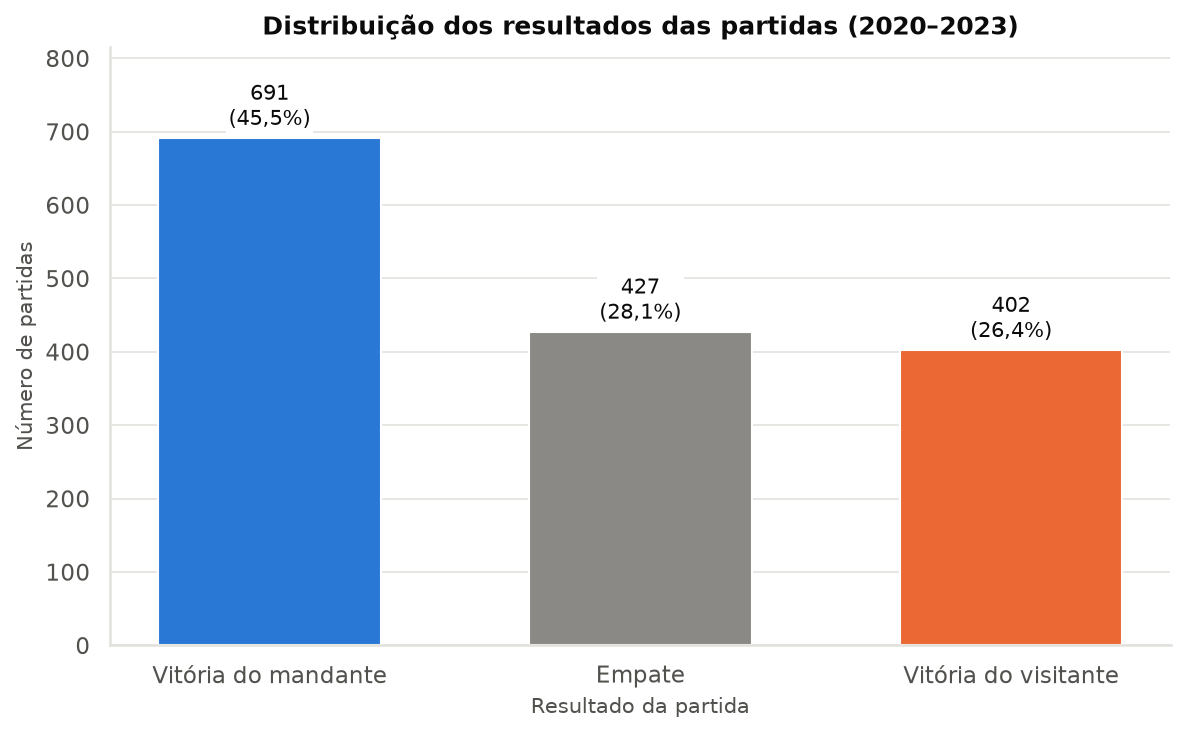

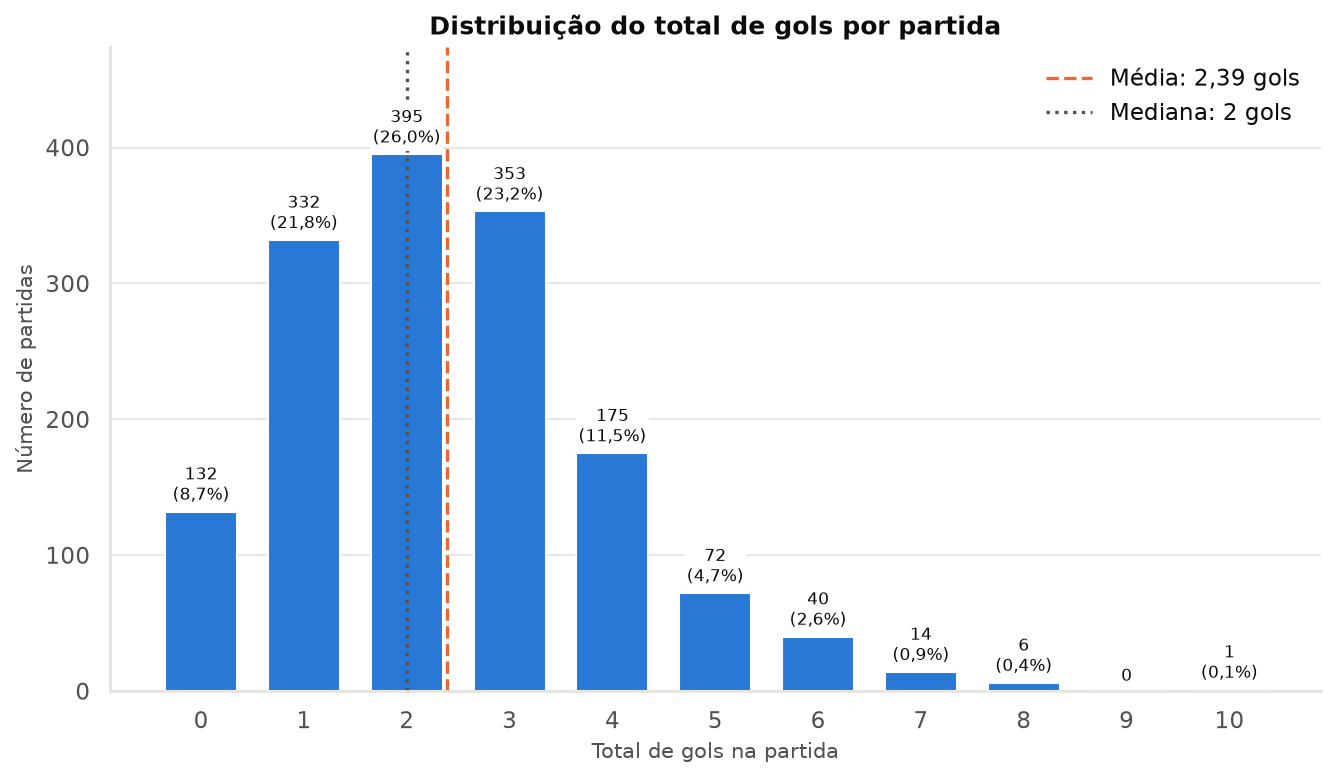

In [29]:
display(Image(filename=str(da.grafico_distribuicao_resultados(df))))
display(Image(filename=str(da.grafico_distribuicao_total_gols(df))))

In [30]:
dist = da.distribuicao_resultados(df).set_index("classe")
display(Markdown(
    f"A classe mais frequente é a vitória do mandante ({da.num(dist.loc['home_win', 'percentual'], 1)}%). "
    f"Um classificador ingênuo que sempre prevê `home_win` acertaria {da.num(dist['percentual'].max(), 1)}% das partidas; "
    "essa é a **linha de base** que qualquer modelo futuro precisa superar."
))

A classe mais frequente é a vitória do mandante (45,5%). Um classificador ingênuo que sempre prevê `home_win` acertaria 45,5% das partidas; essa é a **linha de base** que qualquer modelo futuro precisa superar.

### 7.2 Análise por temporada

In [31]:
tp = da.analise_por_temporada(df)
display(tp["medias"])
display(tp["resultados_pct"])
display(tp["publico"])

,partidas,media_gols,media_gols_mandante,media_gols_visitante,media_amarelos,media_expulsoes,pct_com_expulsao
temporada,,,,,,,
2020,380,2.484,1.411,1.074,4.437,0.287,22.895
2021,380,2.216,1.271,0.945,4.655,0.247,19.211
2022,380,2.382,1.405,0.976,5.105,0.321,25.263
2023,380,2.489,1.418,1.071,5.471,0.321,25.000


resultado,home_win,draw,away_win
temporada,,,
2020,45.000,28.421,26.579
2021,45.789,29.737,24.474
2022,44.211,28.421,27.368
2023,46.842,25.789,27.368


,disponiveis,media,mediana,minimo,maximo
temporada,,,,,
2020,0,<NA>,<NA>,<NA>,<NA>
2021,162,15207.481,9463.500,115.000,61573.000
2022,378,21504.632,18055.000,79.000,69997.000
2023,367,27754.886,27604.000,1943.000,69473.000


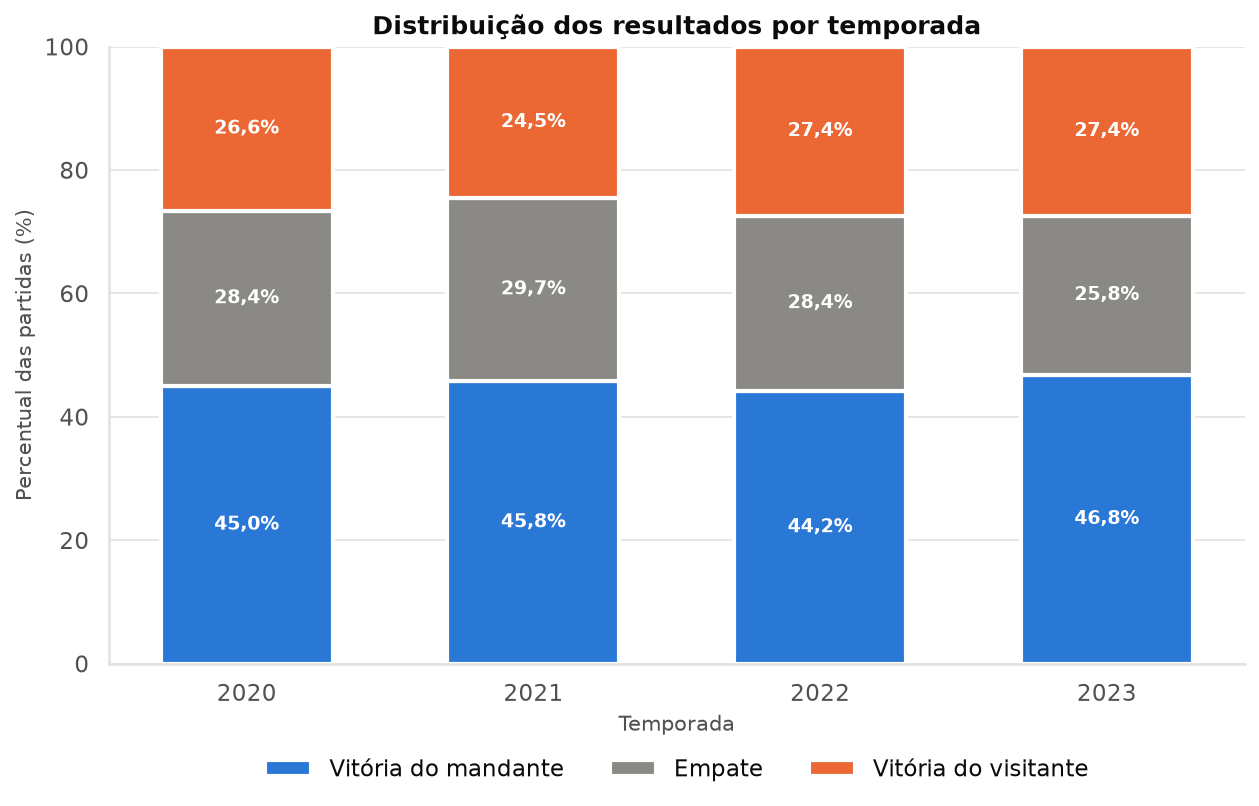

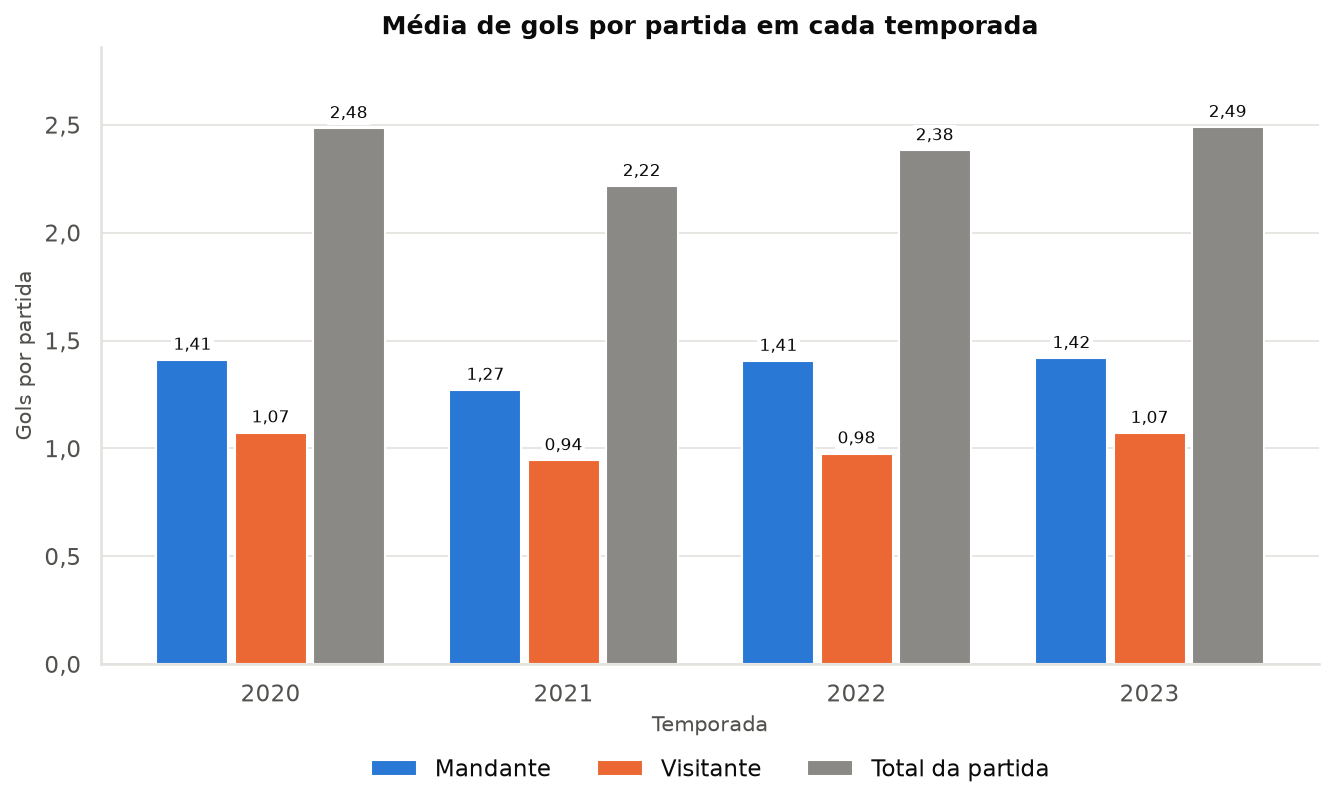

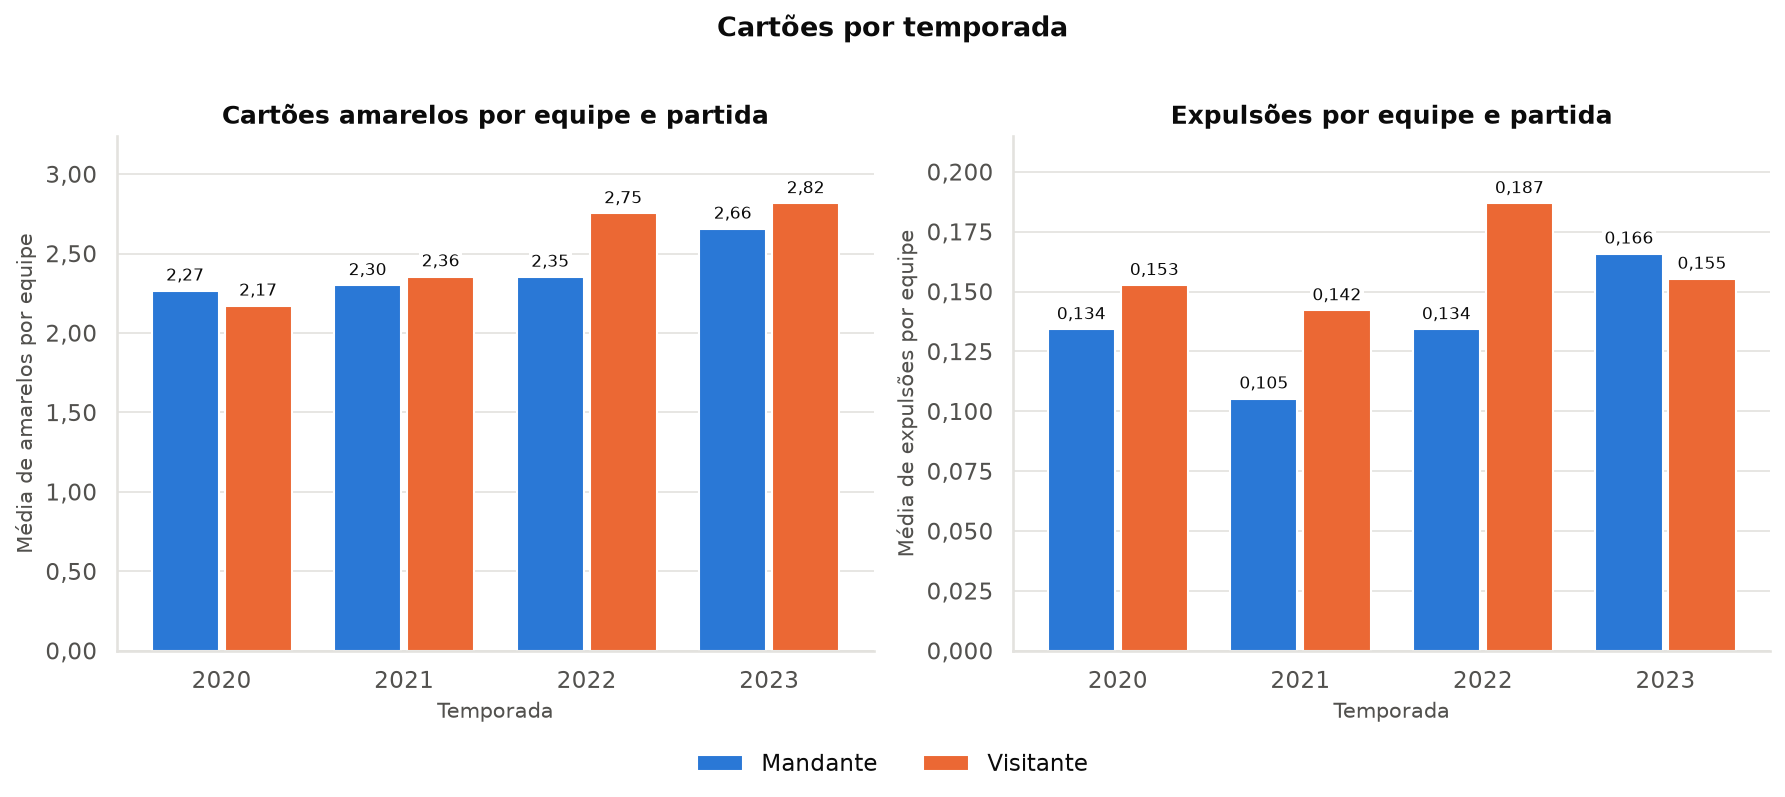

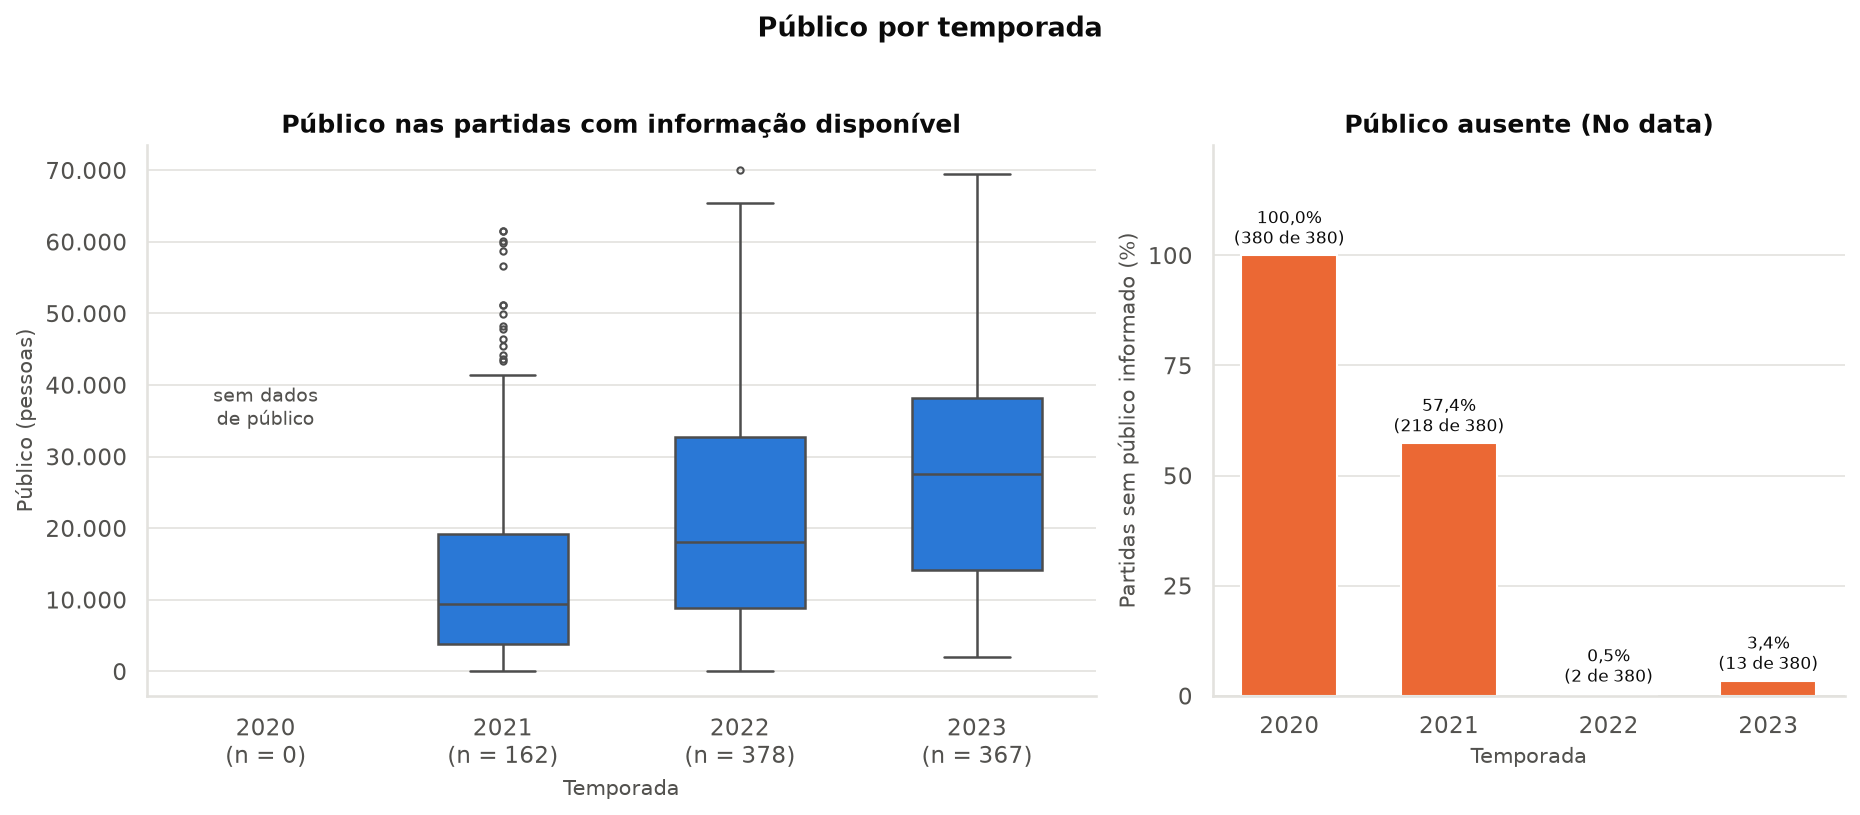

In [32]:
display(Image(filename=str(da.grafico_resultados_por_temporada(df))))
display(Image(filename=str(da.grafico_media_gols_temporada(df))))
display(Image(filename=str(da.grafico_cartoes_temporada(df))))
display(Image(filename=str(da.grafico_publico_por_temporada(df))))

In [33]:
rel = da.relacoes_variaveis(df)
med = tp["medias"]
display(Markdown(
    f"* **Gols:** a média por partida varia de {da.num(med['media_gols'].min(), 2)} ({med['media_gols'].idxmin()}) a {da.num(med['media_gols'].max(), 2)} ({med['media_gols'].idxmax()}); "
    f"Kruskal-Wallis p = {da._p(rel['kruskal_gols_temporada'])}, sem diferença significativa a 5%.\n"
    f"* **Amarelos:** passam de {da.num(med.loc[2020, 'media_amarelos'], 2)} (2020) para {da.num(med.loc[2023, 'media_amarelos'], 2)} (2023); "
    f"Kruskal-Wallis p {da._p(rel['kruskal_amarelos_temporada'])}. A base não explica a causa (arbitragem, coleta ou outro fator).\n"
    f"* **Resultados:** qui-quadrado = {da.num(rel['chi2_resultado_temporada']['chi2'], 2)}, p = {da.num(rel['chi2_resultado_temporada']['p_valor'], 3)}; "
    "sem evidência de que a distribuição das classes mude entre temporadas.\n"
    "* **Público:** calculado só com as partidas que têm informação; 2020 não tem nenhuma (seção 4)."
))

* **Gols:** a média por partida varia de 2,22 (2021) a 2,49 (2023); Kruskal-Wallis p = 0,074, sem diferença significativa a 5%.
* **Amarelos:** passam de 4,44 (2020) para 5,47 (2023); Kruskal-Wallis p < 0,001. A base não explica a causa (arbitragem, coleta ou outro fator).
* **Resultados:** qui-quadrado = 2,24, p = 0,897; sem evidência de que a distribuição das classes mude entre temporadas.
* **Público:** calculado só com as partidas que têm informação; 2020 não tem nenhuma (seção 4).

### 7.3 Análise por equipe

`aproveitamento = pontos_conquistados / pontos_possiveis`, com 3 pontos por vitória e 1 por empate. Equipes disputaram quantidades diferentes de partidas (algumas jogaram uma só temporada), então os rankings de **totais** favorecem quem esteve em mais temporadas. Rankings baseados em **médias** exigem um mínimo de `MIN_PARTIDAS_RANKING` partidas.

In [34]:
equipes = da.estatisticas_por_equipe(df)
print("Mínimo de partidas para rankings de médias:", da.MIN_PARTIDAS_RANKING)
equipes

Mínimo de partidas para rankings de médias: 38


,equipe,partidas,vitorias,empates,derrotas,pontos,gols_marcados,gols_sofridos,amarelos,expulsoes,aproveitamento,temporadas,saldo_gols,media_gols_marcados,media_gols_sofridos,media_amarelos,media_expulsoes,partidas_casa,vitorias_casa,empates_casa,derrotas_casa,pontos_casa,gols_marcados_casa,gols_sofridos_casa,aproveitamento_casa,partidas_fora,vitorias_fora,empates_fora,derrotas_fora,pontos_fora,gols_marcados_fora,gols_sofridos_fora,aproveitamento_fora
0,Clube Atlético Mineiro,152,80,36,36,276,228,148,351,15,0.605,4,80,1.500,0.974,2.309,0.099,76,50,13,13,163,136,60,0.715,76,30,23,23,113,92,88,0.496
1,SE Palmeiras,152,78,41,33,275,239,140,356,25,0.603,4,99,1.572,0.921,2.342,0.164,76,47,17,12,158,140,66,0.693,76,31,24,21,117,99,74,0.513
2,CR Flamengo,152,79,33,40,270,253,165,344,15,0.592,4,88,1.664,1.086,2.263,0.099,76,45,13,18,148,129,69,0.649,76,34,20,22,122,124,96,0.535
3,SC Internacional,152,67,45,40,246,209,153,404,30,0.539,4,56,1.375,1.007,2.658,0.197,76,42,21,13,147,133,74,0.645,76,25,24,27,99,76,79,0.434
4,Fluminense FC,152,70,34,48,244,207,168,383,27,0.535,4,39,1.362,1.105,2.520,0.178,76,47,17,12,158,127,66,0.693,76,23,17,36,86,80,102,0.377
5,SC Corinthians Paulista,152,58,49,45,223,176,165,318,19,0.489,4,11,1.158,1.086,2.092,0.125,76,36,26,14,134,105,75,0.588,76,22,23,31,89,71,90,0.390
6,São Paulo FC,152,56,53,43,221,185,160,399,19,0.485,4,25,1.217,1.053,2.625,0.125,76,38,25,13,139,108,65,0.610,76,18,28,30,82,77,95,0.360
7,Red Bull Bragantino,152,55,50,47,215,203,180,372,20,0.471,4,23,1.336,1.184,2.447,0.132,76,36,24,16,132,119,76,0.579,76,19,26,31,83,84,104,0.364
8,Club Athletico Paranaense,152,58,40,54,214,178,172,371,14,0.469,4,6,1.171,1.132,2.441,0.092,76,38,24,14,138,107,70,0.605,76,20,16,40,76,71,102,0.333
9,Fortaleza EC,152,57,37,58,208,169,172,354,19,0.456,4,-3,1.112,1.132,2.329,0.125,76,35,24,17,129,98,67,0.566,76,22,13,41,79,71,105,0.346


In [35]:
rk = da.rankings(equipes)
titulos = {"mais_vitorias": "Mais vitórias", "melhores_aproveitamentos": "Melhores aproveitamentos",
           "maiores_medias_gols": "Maiores médias de gols marcados", "melhores_saldos": "Melhores saldos de gols",
           "mais_amarelos": "Mais cartões amarelos", "mais_expulsoes": "Mais expulsões"}
for chave, titulo in titulos.items():
    display(Markdown(f"**{titulo}**"))
    display(rk[chave].reset_index(drop=True))

**Mais vitórias**

,equipe,partidas,vitorias,aproveitamento
0,Clube Atlético Mineiro,152,80,0.605
1,CR Flamengo,152,79,0.592
2,SE Palmeiras,152,78,0.603
3,Fluminense FC,152,70,0.535
4,SC Internacional,152,67,0.539
5,SC Corinthians Paulista,152,58,0.489
6,Club Athletico Paranaense,152,58,0.469
7,Fortaleza EC,152,57,0.456
8,São Paulo FC,152,56,0.485
9,Red Bull Bragantino,152,55,0.471


**Melhores aproveitamentos**

,equipe,partidas,pontos,aproveitamento
0,Clube Atlético Mineiro,152,276,0.605
1,SE Palmeiras,152,275,0.603
2,CR Flamengo,152,270,0.592
3,SC Internacional,152,246,0.539
4,Fluminense FC,152,244,0.535
5,Grêmio FB Porto Alegrense,114,170,0.497
6,SC Corinthians Paulista,152,223,0.489
7,São Paulo FC,152,221,0.485
8,Red Bull Bragantino,152,215,0.471
9,Club Athletico Paranaense,152,214,0.469


**Maiores médias de gols marcados**

...

,equipe,partidas,gols_marcados,gols_sofridos,saldo_gols
0,SE Palmeiras,152,239,140,99
1,CR Flamengo,152,253,165,88
2,Clube Atlético Mineiro,152,228,148,80
3,SC Internacional,152,209,153,56
4,Fluminense FC,152,207,168,39
5,São Paulo FC,152,185,160,25
6,Red Bull Bragantino,152,203,180,23
7,Grêmio FB Porto Alegrense,114,160,147,13
8,SC Corinthians Paulista,152,176,165,11
9,Club Athletico Paranaense,152,178,172,6


**Mais cartões amarelos**

,equipe,partidas,amarelos,media_amarelos
0,SC Internacional,152,404,2.658
1,São Paulo FC,152,399,2.625
2,Santos FC Sao Paulo,152,390,2.566
3,Fluminense FC,152,383,2.520
4,Red Bull Bragantino,152,372,2.447
5,Club Athletico Paranaense,152,371,2.441
6,SE Palmeiras,152,356,2.342
7,Fortaleza EC,152,354,2.329
8,Clube Atlético Mineiro,152,351,2.309
9,CR Flamengo,152,344,2.263


**Mais expulsões**

,equipe,partidas,expulsoes,media_expulsoes
0,SC Internacional,152,30,0.197
1,Fluminense FC,152,27,0.178
2,Coritiba FBC,114,26,0.228
3,SE Palmeiras,152,25,0.164
4,Ceará SC,114,22,0.193
5,Grêmio FB Porto Alegrense,114,21,0.184
6,Red Bull Bragantino,152,20,0.132
7,Santos FC Sao Paulo,152,20,0.132
8,Cuiabá EC,114,19,0.167
9,SC Corinthians Paulista,152,19,0.125


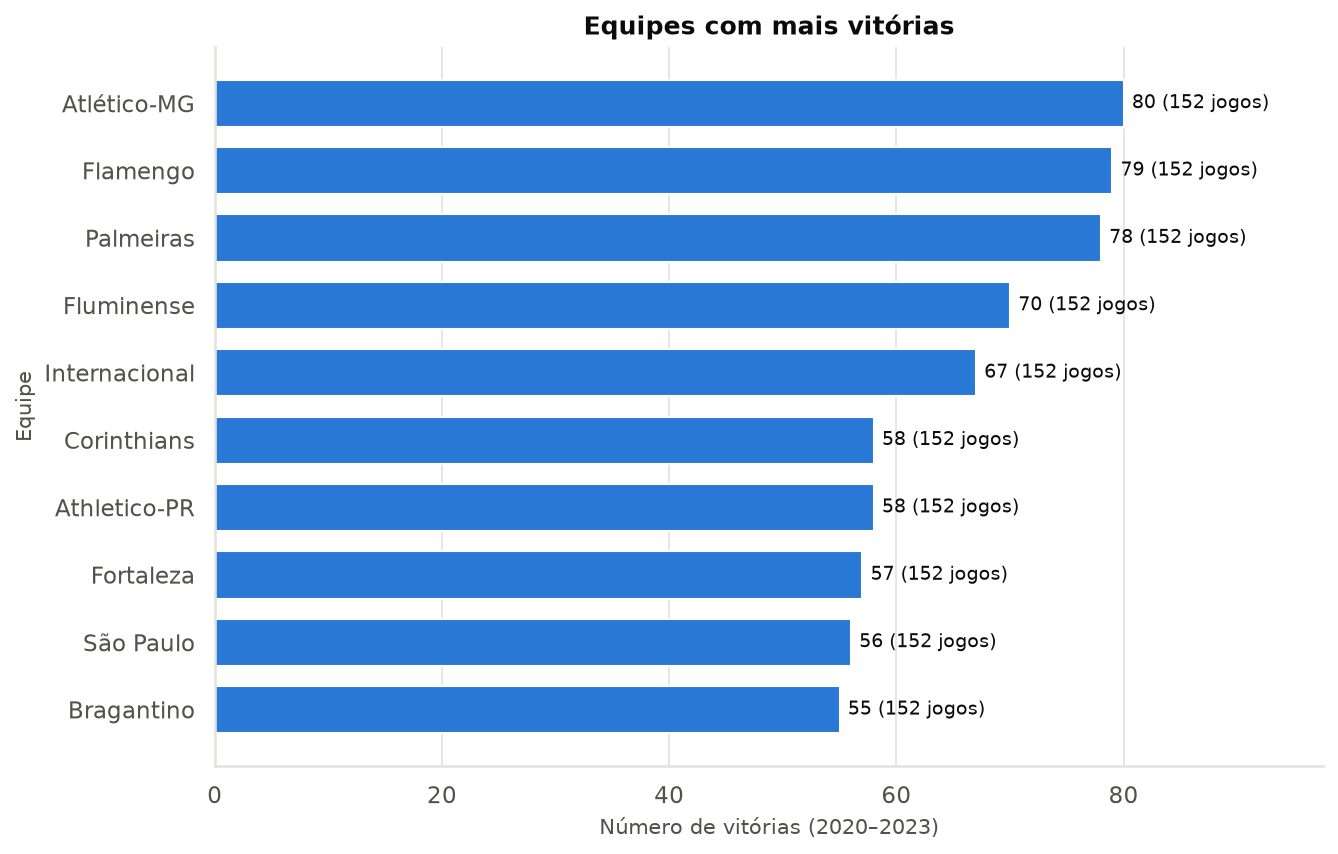

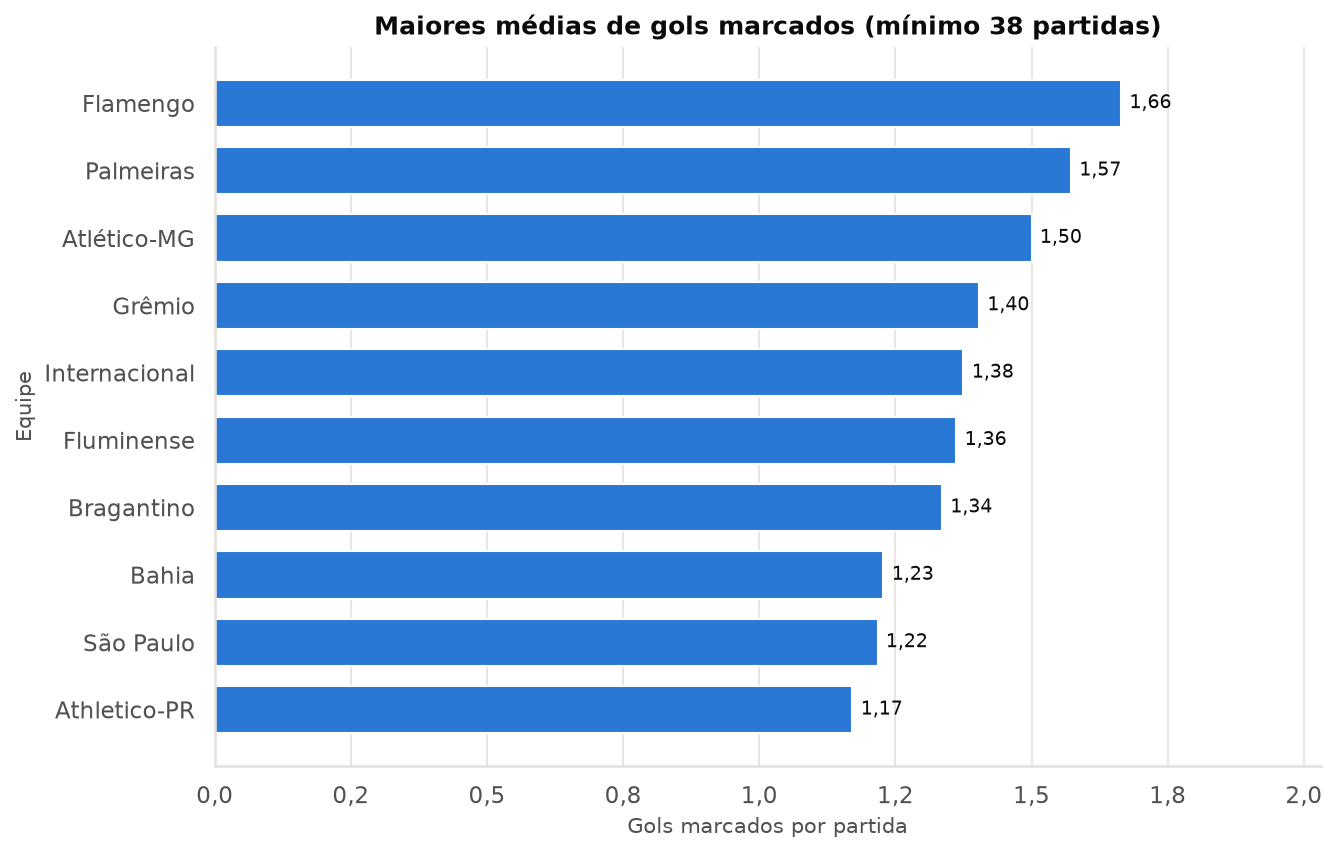

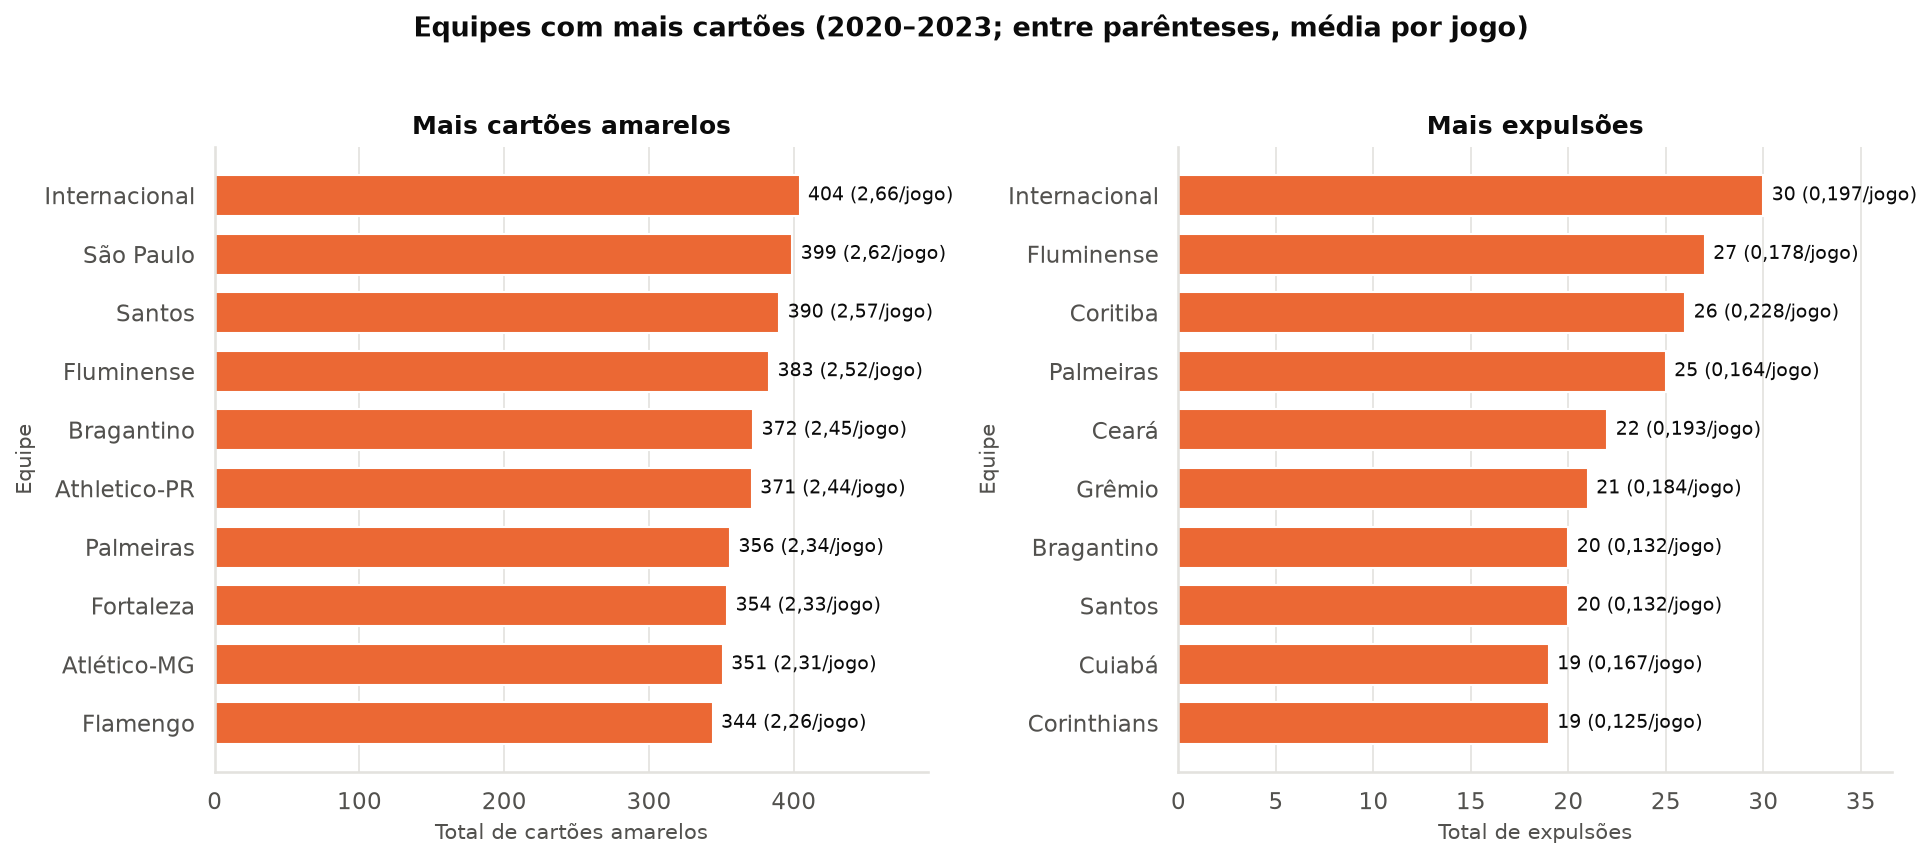

In [36]:
display(Image(filename=str(da.grafico_times_mais_vitoriosos(equipes))))
display(Image(filename=str(da.grafico_times_maior_media_gols(equipes))))
display(Image(filename=str(da.grafico_times_mais_cartoes(equipes))))

In [37]:
elegiveis = equipes[equipes["partidas"] >= da.MIN_PARTIDAS_RANKING]
n_casa = int((equipes["aproveitamento_casa"] > equipes["aproveitamento_fora"]).sum())
display(Markdown(
    f"* {n_casa} das {len(equipes)} equipes tiveram aproveitamento maior como **mandante** do que como **visitante**.\n"
    f"* {int((equipes['temporadas'] == 4).sum())} equipes disputaram as quatro temporadas; {int((equipes['temporadas'] < 4).sum())} não.\n"
    f"* {len(elegiveis)} das {len(equipes)} equipes atingem o mínimo de {da.MIN_PARTIDAS_RANKING} partidas (uma temporada completa) exigido nos rankings de médias.\n"
    "* Rankings de totais (vitórias, cartões) devem ser lidos junto com a coluna `partidas`."
))

* 24 das 26 equipes tiveram aproveitamento maior como **mandante** do que como **visitante**.
* 11 equipes disputaram as quatro temporadas; 15 não.
* 26 das 26 equipes atingem o mínimo de 38 partidas (uma temporada completa) exigido nos rankings de médias.
* Rankings de totais (vitórias, cartões) devem ser lidos junto com a coluna `partidas`.

#### Desempenho de uma mesma equipe entre temporadas

In [38]:
et = da.desempenho_equipe_por_temporada(df)
completas = et.dropna()
completas.assign(amplitude=completas.max(axis=1) - completas.min(axis=1)).sort_values("amplitude", ascending=False)

temporada,2020,2021,2022,2023,amplitude
equipe,,,,,
Clube Atlético Mineiro,0.596,0.737,0.509,0.579,0.228
SC Internacional,0.614,0.421,0.640,0.482,0.219
SE Palmeiras,0.509,0.579,0.711,0.614,0.202
Red Bull Bragantino,0.465,0.491,0.386,0.544,0.158
São Paulo FC,0.579,0.421,0.474,0.465,0.158
Fortaleza EC,0.360,0.509,0.482,0.474,0.149
Fluminense FC,0.561,0.474,0.614,0.491,0.140
SC Corinthians Paulista,0.447,0.500,0.570,0.439,0.132
Club Athletico Paranaense,0.465,0.412,0.509,0.491,0.096


In [39]:
top = (completas.max(axis=1) - completas.min(axis=1)).sort_values(ascending=False)
display(Markdown(
    f"Entre as {len(completas)} equipes presentes nas quatro temporadas, a maior variação de aproveitamento entre temporadas foi de "
    f"**{da.num(top.iloc[0] * 100, 1)} pontos percentuais** ({top.index[0]}). Médias de quatro anos escondem essa variação."
))

Entre as 11 equipes presentes nas quatro temporadas, a maior variação de aproveitamento entre temporadas foi de **22,8 pontos percentuais** (Clube Atlético Mineiro). Médias de quatro anos escondem essa variação.

### 7.4 Relações entre variáveis

As relações abaixo são **descritivas**. Associação ou correlação **não prova causalidade**.

**Mando de campo e resultado**

,mandante,visitante
vitórias,691.000,402.000
empates,427.000,427.000
derrotas,402.000,691.000
aproveitamento,0.548,0.358


691 vitórias de mandantes contra 402 de visitantes (teste binomial entre partidas com vencedor: p < 0,001).

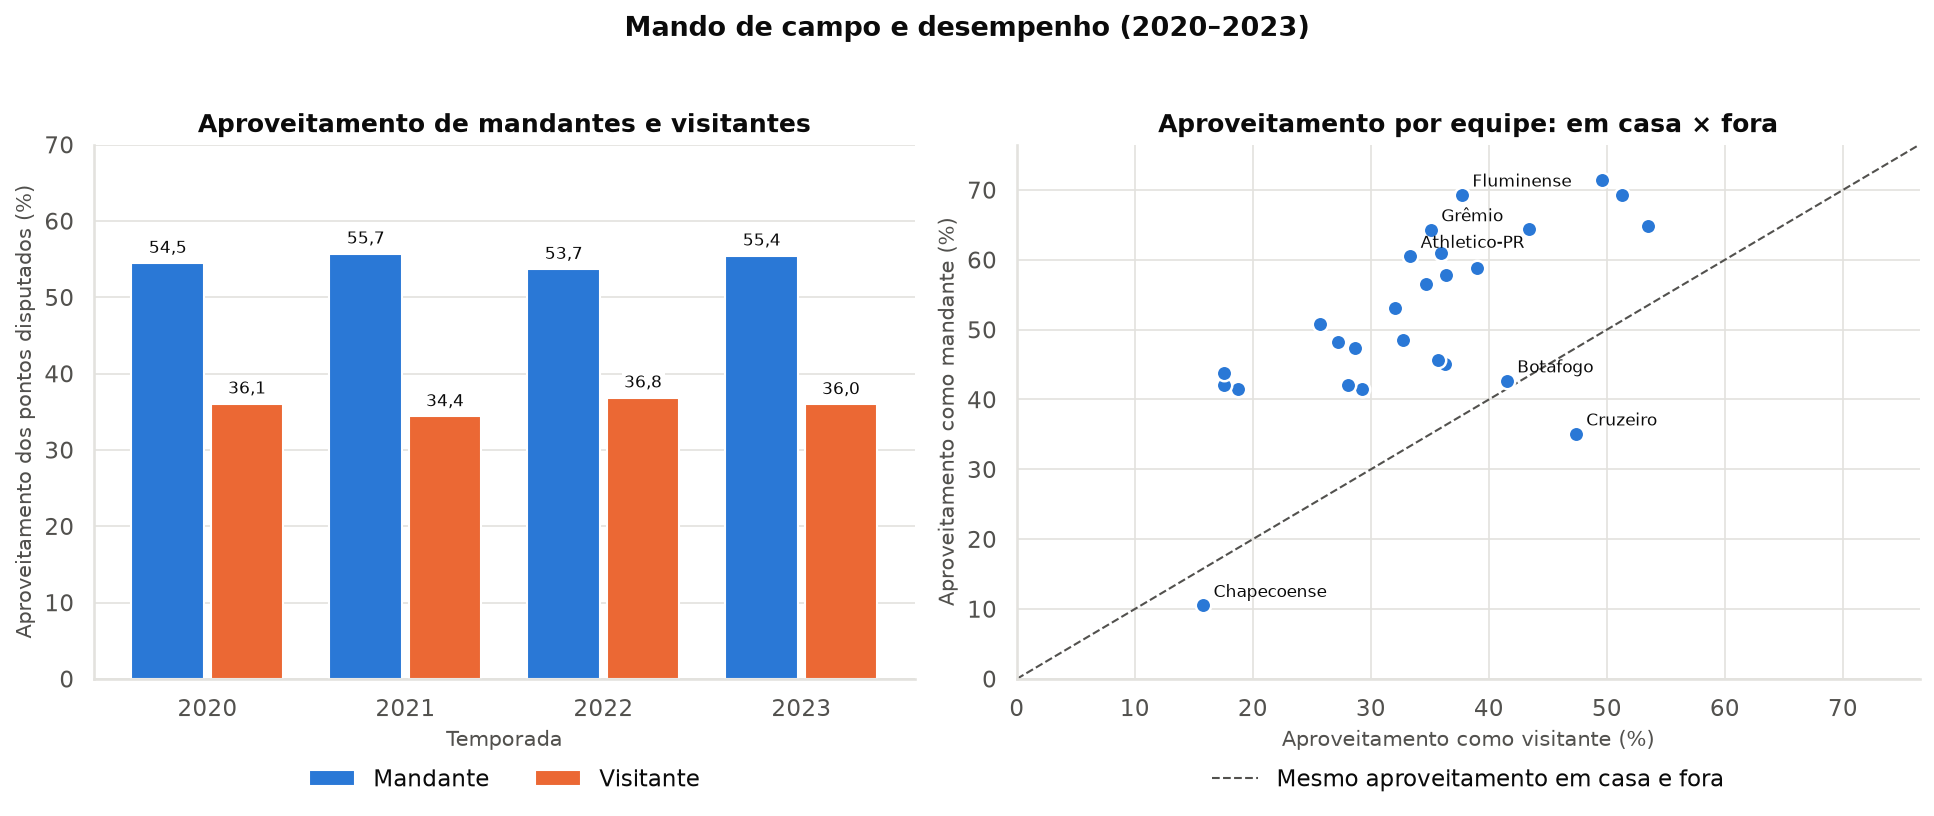

In [40]:
display(rel["mando"])
display(Markdown(
    f"{rel['teste_mando']['vitorias_mandante']} vitórias de mandantes contra {rel['teste_mando']['vitorias_visitante']} de visitantes "
    f"(teste binomial entre partidas com vencedor: p {da._p(rel['teste_mando']['p_valor'])})."
))
display(Image(filename=str(da.grafico_mando_campo_resultado(df, equipes))))

**Gols e resultado** — o resultado é definido pelo placar, portanto esta relação é uma consequência direta, não uma descoberta.

In [41]:
rel["gols_por_resultado"]

,home_team_score,away_team_score,total_gols
resultado,,,
home_win,2.153,0.486,2.640
draw,0.916,0.916,1.831
away_win,0.530,2.035,2.565


**Cartões amarelos e resultado**

In [42]:
rel["amarelos_por_resultado"]

,amarelos_mandante,amarelos_visitante,total_amarelos
resultado,,,
home_win,2.333,2.425,4.758
draw,2.424,2.560,4.984
away_win,2.465,2.654,5.119


**Expulsões e resultado.** A base não informa o placar no momento de cada expulsão. Uma equipe pode receber expulsão porque já estava perdendo (ou ganhando), então a tabela não separa o efeito da expulsão da situação de jogo que a antecedeu.

In [43]:
rel["expulsoes_resultado"]

,situação,partidas,home_win (%),draw (%),away_win (%)
0,Sem expulsão na partida,1169,46.022,28.229,25.749
1,Expulsão apenas do mandante,137,24.088,28.467,47.445
2,Expulsão apenas do visitante,171,63.158,23.392,13.450
3,Expulsão dos dois times,43,27.907,41.860,30.233


**Público e gols / público e resultado** (somente partidas com público informado)

In [44]:
display(Markdown(
    f"Correlação de Spearman entre público e total de gols: **{da.num(rel['publico_gols']['rho'], 3)}** "
    f"(n = {rel['publico_gols']['n']}, p = {da._p(rel['publico_gols']['p_valor'])})."
))
display(rel["publico_por_resultado"])
display(Markdown(
    f"Kruskal-Wallis do público entre as três classes: p = {da._p(rel['kruskal_publico_resultado'])}. "
    "O público depende do mandante (equipes com mais torcida têm mais público e também tendem a vencer mais em casa) e da temporada; "
    "por isso a associação **não** deve ser lida como o público influenciando o resultado."
))

Correlação de Spearman entre público e total de gols: **0,035** (n = 907, p = 0,286).

,count,mean,median
resultado,,,
home_win,432,24304.095,21670.000
draw,241,22116.133,18686.000
away_win,234,21149.782,17627.500


Kruskal-Wallis do público entre as três classes: p = 0,025. O público depende do mandante (equipes com mais torcida têm mais público e também tendem a vencer mais em casa) e da temporada; por isso a associação **não** deve ser lida como o público influenciando o resultado.

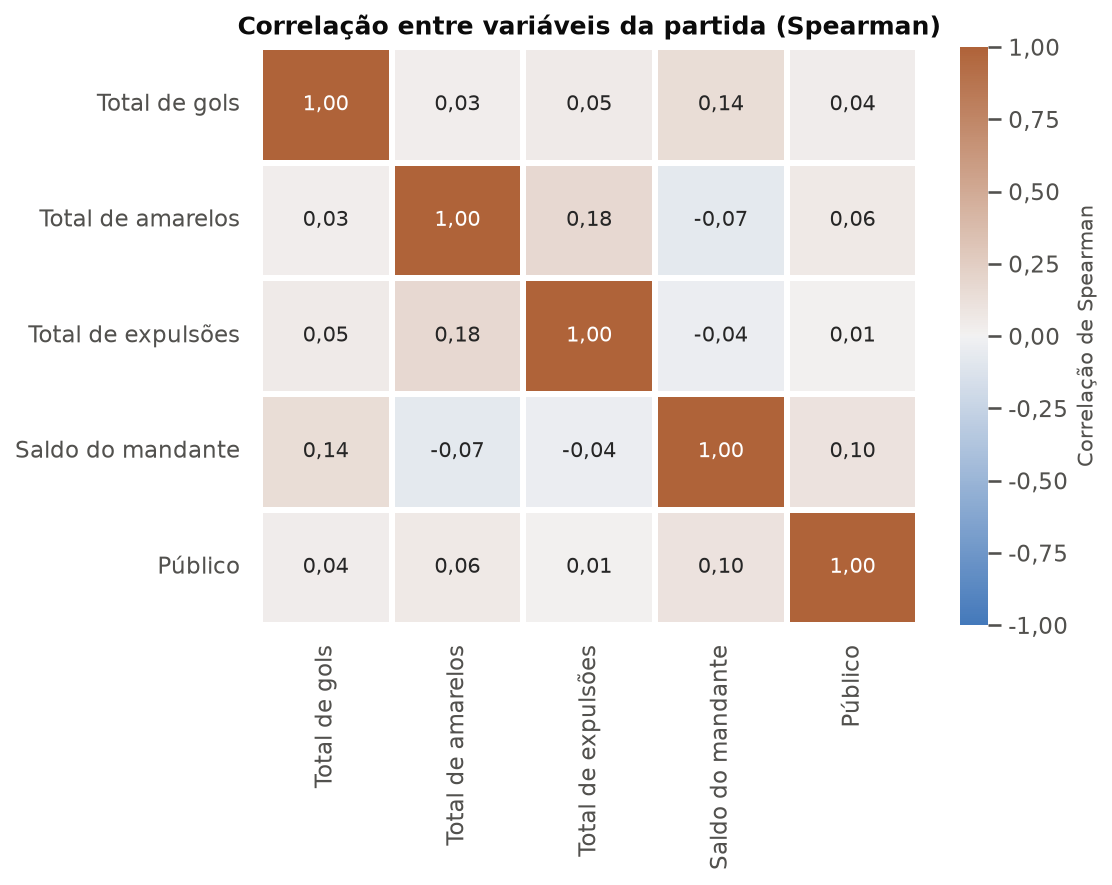

In [45]:
display(Image(filename=str(da.grafico_correlacao(df))))

## 8. Valores extremos (outliers)

Método: estatísticas descritivas, boxplots, intervalo interquartil (IQR = Q3 − Q1; limites em Q1 − 1,5·IQR e Q3 + 1,5·IQR) e inspeção das linhas extremas. **Nenhum valor é removido apenas por ser extremo**; a pergunta é se é um evento real ou um erro de coleta.

In [46]:
out = da.analise_outliers(df)
out["iqr"]

,variável,Q1,Q3,limite inferior,limite superior,abaixo,acima,mínimo,máximo
0,Gols na partida,1.000,3.000,-2.000,6.000,0,21,0.000,10.000
1,Amarelos na partida,3.000,6.000,-1.500,10.500,0,23,0.000,15.000
2,Expulsões na partida,0.000,0.000,0.000,0.000,0,351,0.000,5.000
3,Público,9157.000,35815.500,-30830.750,75803.250,0,0,79.000,69997.000


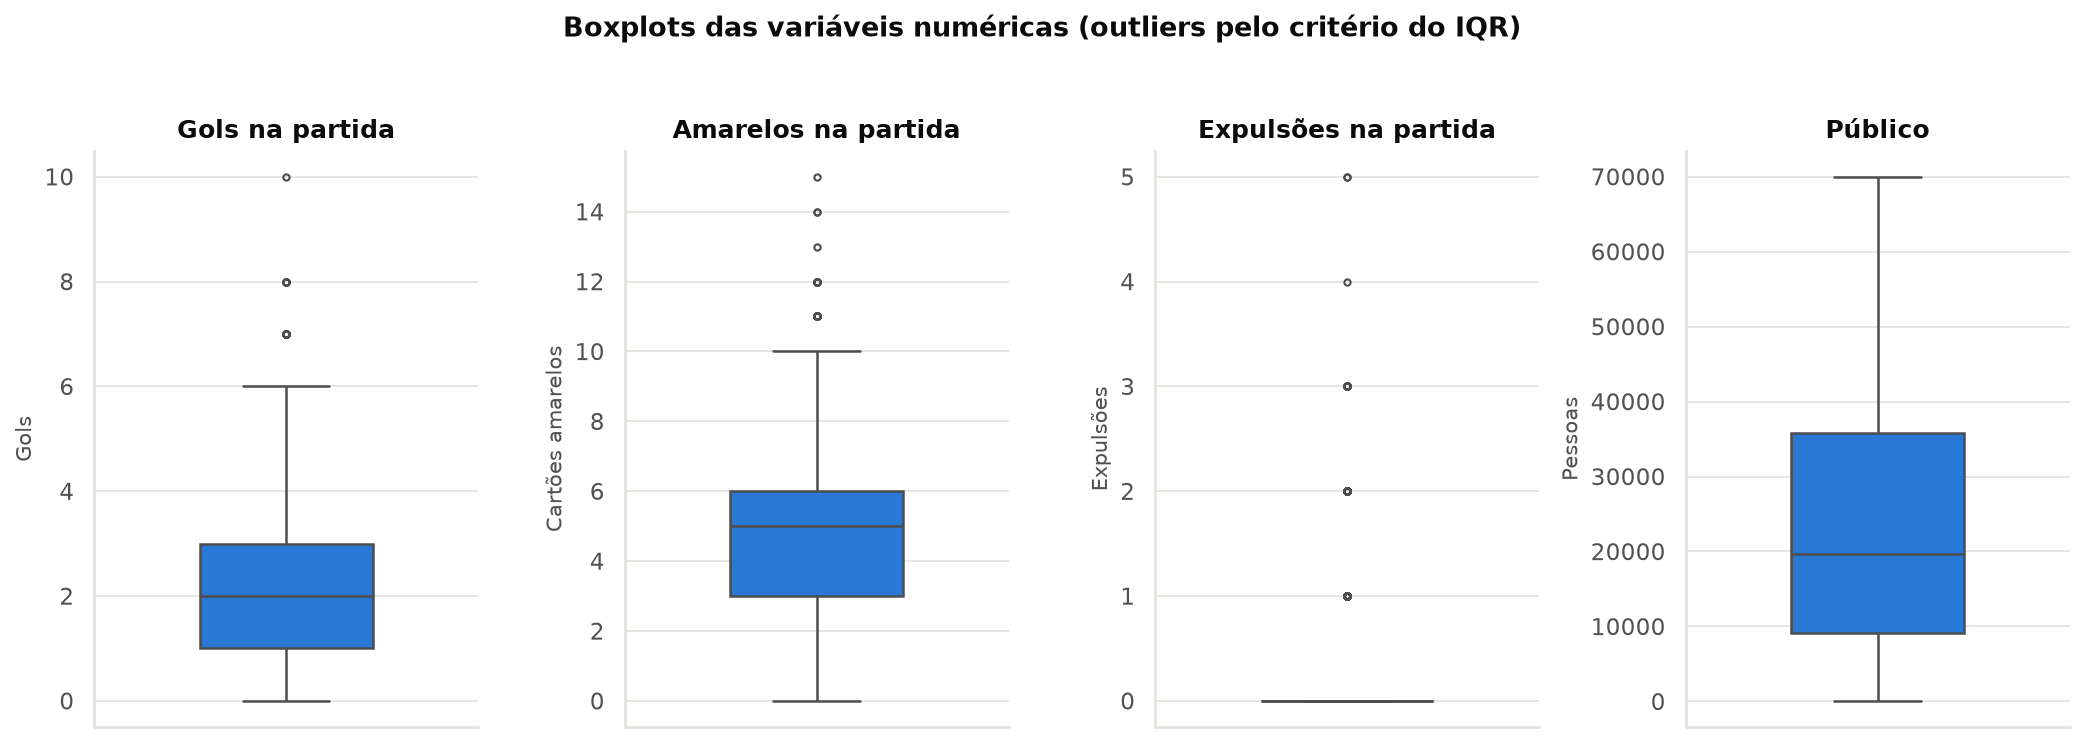

In [47]:
display(Image(filename=str(da.grafico_boxplots_outliers(df))))

In [48]:
display(Markdown("**Maiores placares**"))
display(out["maiores_placares"])
display(Markdown("**Mais cartões amarelos**"))
display(out["mais_amarelos"])
display(Markdown("**Mais expulsões**"))
display(out["mais_expulsoes"])

**Maiores placares**

,id_partida,temporada,data_partida,home_team,away_team,home_team_score,away_team_score,total_gols,total_amarelos,total_expulsoes,publico,stadium
1390,1391,2023,2023-10-07 16:00:00,Goiás EC,EC Bahia,4,6,10,4,0,9001,Estádio Hailé Pinheiro (Serrinha)
59,60,2020,2020-09-02 20:30:00,EC Bahia,CR Flamengo,3,5,8,3,0,<NA>,Pituaçu
150,151,2020,2020-10-14 21:30:00,SC do Recife,SC Internacional,3,5,8,5,0,<NA>,Ilha do Retiro
855,856,2022,2022-06-08 21:30:00,Fluminense FC,Clube Atlético Mineiro,5,3,8,8,0,16143,Estádio Jornalista Mário Filho (Maracanã)
1368,1369,2023,2023-09-18 21:00:00,SC Corinthians Paulista,Grêmio FB Porto Alegrense,4,4,8,2,0,35796,Neo Química Arena
1416,1417,2023,2023-10-22 16:00:00,SC Internacional,Santos FC Sao Paulo,7,1,8,2,0,36584,Beira-Rio
1420,1421,2023,2023-10-25 19:00:00,Fluminense FC,Goiás EC,5,3,8,6,0,4793,Estádio Municipal General Raulino de Oliveira
98,99,2020,2020-09-19 21:00:00,Atlético Goianiense,Clube Atlético Mineiro,3,4,7,2,0,<NA>,Estádio Olímpico Pedro Ludovico Teixeira


**Mais cartões amarelos**

,id_partida,temporada,data_partida,home_team,away_team,home_team_score,away_team_score,total_gols,total_amarelos,total_expulsoes,publico,stadium
762,763,2022,2022-04-09 21:00:00,SE Palmeiras,Ceará SC,2,3,5,15,1,27100,Allianz Parque
1269,1270,2023,2023-07-03 20:00:00,Goiás EC,Coritiba FBC,1,2,3,14,0,10394,Estádio Hailé Pinheiro (Serrinha)
1282,1283,2023,2023-07-16 16:00:00,Fluminense FC,CR Flamengo,0,0,0,14,1,62354,Estádio Jornalista Mário Filho (Maracanã)
52,53,2020,2020-08-30 16:00:00,Santos FC Sao Paulo,CR Flamengo,0,1,1,13,0,<NA>,Vila Belmiro
179,180,2020,2020-11-01 20:30:00,Goiás EC,CR Vasco da Gama,1,1,2,12,0,<NA>,Estádio Hailé Pinheiro (Serrinha)
906,907,2022,2022-07-03 16:00:00,Atlético Goianiense,São Paulo FC,1,2,3,12,0,12089,Estádio Antônio Accioly
1000,1001,2022,2022-09-03 16:30:00,EC Juventude,Avai FC,1,1,2,12,0,2708,Alfredo Jaconi
1221,1222,2023,2023-06-03 18:30:00,Cruzeiro EC,Clube Atlético Mineiro,0,1,1,12,0,34310,Estádio Municipal João Havelange


**Mais expulsões**

,id_partida,temporada,data_partida,home_team,away_team,home_team_score,away_team_score,total_gols,total_amarelos,total_expulsoes,publico,stadium
885,886,2022,2022-06-19 18:00:00,SC Internacional,Botafogo FR,2,3,5,11,5,26219,Beira-Rio
1023,1024,2022,2022-09-18 16:00:00,CR Flamengo,Fluminense FC,1,2,3,6,5,55170,Estádio Jornalista Mário Filho (Maracanã)
67,68,2020,2020-09-05 21:00:00,Ceará SC,Santos FC Sao Paulo,0,1,1,7,4,<NA>,Castelão
433,434,2021,2021-06-24 19:00:00,Chapecoense AF,SC Internacional,1,2,3,5,3,<NA>,Arena Condá
527,528,2021,2021-08-14 19:00:00,Clube Atlético Mineiro,SE Palmeiras,2,0,2,4,3,<NA>,Mineirão
688,689,2021,2021-11-11 19:00:00,CR Flamengo,EC Bahia,3,0,3,2,3,9488,Estádio Jornalista Mário Filho (Maracanã)
695,696,2021,2021-11-14 18:15:00,Fluminense FC,SE Palmeiras,2,1,3,11,3,7969,Estádio Jornalista Mário Filho (Maracanã)
825,826,2022,2022-05-21 21:00:00,Cuiabá EC,SC Internacional,1,1,2,10,3,7968,Arena Pantanal


In [49]:
display(Markdown("**Menores públicos**"))
display(out["menores_publicos"])
display(Markdown("**Maiores públicos**"))
display(out["maiores_publicos"])

**Menores públicos**

,id_partida,temporada,data_partida,home_team,away_team,home_team_score,away_team_score,total_gols,total_amarelos,total_expulsoes,publico,stadium
1075,1076,2022,2022-10-16 19:00:00,Avai FC,Fluminense FC,0,3,3,2,0,79,Ressacada
573,574,2021,2021-09-18 17:00:00,Chapecoense AF,SE Palmeiras,0,2,2,4,0,115,Arena Condá
605,606,2021,2021-10-06 19:00:00,Chapecoense AF,Clube Atlético Mineiro,2,2,4,3,0,733,Arena Condá
633,634,2021,2021-10-16 21:00:00,América FC (Minas Gerais),EC Bahia,0,0,0,3,0,746,Estádio Raimundo Sampaio
609,610,2021,2021-10-06 21:30:00,América FC (Minas Gerais),SE Palmeiras,2,1,3,5,0,854,Estádio Raimundo Sampaio
656,657,2021,2021-10-28 19:00:00,Red Bull Bragantino,SC do Recife,3,0,3,9,0,931,Nabizão
626,627,2021,2021-10-13 19:00:00,Chapecoense AF,Club Athletico Paranaense,1,1,2,9,0,935,Arena Condá
622,623,2021,2021-10-12 19:00:00,Red Bull Bragantino,Atlético Goianiense,1,0,1,6,1,971,Nabizão


**Maiores públicos**

,id_partida,temporada,data_partida,home_team,away_team,home_team_score,away_team_score,total_gols,total_amarelos,total_expulsoes,publico,stadium
780,781,2022,2022-04-20 19:30:00,CR Flamengo,SE Palmeiras,0,0,0,7,0,69997,Estádio Jornalista Mário Filho (Maracanã)
1414,1415,2023,2023-10-22 16:00:00,CR Flamengo,CR Vasco da Gama,1,0,1,3,0,69473,Estádio Jornalista Mário Filho (Maracanã)
1288,1289,2023,2023-07-22 16:00:00,CR Flamengo,América FC (Minas Gerais),1,1,2,6,0,65402,Estádio Jornalista Mário Filho (Maracanã)
934,935,2022,2022-07-20 20:30:00,CR Flamengo,EC Juventude,4,0,4,6,1,65392,Estádio Nacional
1492,1493,2023,2023-11-29 19:30:00,CR Flamengo,Clube Atlético Mineiro,0,3,3,5,0,65305,Estádio Jornalista Mário Filho (Maracanã)
1212,1213,2023,2023-05-27 18:30:00,CR Flamengo,Cruzeiro EC,1,1,2,9,0,65270,Estádio Jornalista Mário Filho (Maracanã)
1207,1208,2023,2023-05-21 16:00:00,CR Flamengo,SC Corinthians Paulista,1,0,1,2,0,64871,Estádio Jornalista Mário Filho (Maracanã)
1440,1441,2023,2023-11-01 20:00:00,CR Flamengo,Santos FC Sao Paulo,1,2,3,4,3,64708,Estádio Nacional


In [50]:
menor = out["menores_publicos"].iloc[0]
outros = df[(df["stadium"] == menor["stadium"]) & (df["id_partida"] != menor["id_partida"])]["publico"].dropna().astype(float)
mp = out["maiores_placares"].iloc[0]
display(Markdown(
    f"* **Placares altos:** o maior total é {int(mp['total_gols'])} gols ({mp['home_team']} {int(mp['home_team_score'])} × {int(mp['away_team_score'])} {mp['away_team']}). "
    f"Como o número de eventos de gol coincide com o placar em todas as {len(df)} partidas (seção 5.1), esses jogos são consistentes com eventos reais.\n"
    "* **Expulsões:** como Q1 = Q3 = 0, o IQR marca qualquer partida com expulsão como outlier, o que é pouco informativo para uma contagem com muitos zeros; a decisão usa a inspeção direta das linhas.\n"
    f"* **Público suspeito:** {menor['home_team']} × {menor['away_team']} ({menor['data_partida']:%d/%m/%Y}) tem {int(menor['publico'])} pessoas; "
    f"nas outras {len(outros)} partidas com público informado em {menor['stadium']}, o mínimo é {da.mil(outros.min())} e a mediana {da.mil(outros.median())}. "
    "Pode ser erro de coleta, mas não há como confirmá-lo com estes dados: **mantido e sinalizado**.\n"
    "* **Decisão geral:** nenhum registro foi removido."
))

* **Placares altos:** o maior total é 10 gols (Goiás EC 4 × 6 EC Bahia). Como o número de eventos de gol coincide com o placar em todas as 1520 partidas (seção 5.1), esses jogos são consistentes com eventos reais.
* **Expulsões:** como Q1 = Q3 = 0, o IQR marca qualquer partida com expulsão como outlier, o que é pouco informativo para uma contagem com muitos zeros; a decisão usa a inspeção direta das linhas.
* **Público suspeito:** Avai FC × Fluminense FC (16/10/2022) tem 79 pessoas; nas outras 18 partidas com público informado em Ressacada, o mínimo é 2.025 e a mediana 9.146. Pode ser erro de coleta, mas não há como confirmá-lo com estes dados: **mantido e sinalizado**.
* **Decisão geral:** nenhum registro foi removido.

## 9. Preparação para Machine Learning

### 9.1 Colunas proibidas (vazamento de dados)

Prever **antes** da partida significa usar somente informação disponível **antes** dela. As colunas abaixo descrevem o que aconteceu **na própria partida** e são **proibidas como variáveis de entrada** do modelo.

In [51]:
pd.DataFrame({"coluna proibida": da.COLUNAS_PROIBIDAS_OBRIGATORIAS,
              "motivo": "descreve o resultado, o placar ou eventos da própria partida"})

,coluna proibida,motivo
0,home_team_score,"descreve o resultado, o placar ou eventos da p..."
1,away_team_score,"descreve o resultado, o placar ou eventos da p..."
2,gols_home,"descreve o resultado, o placar ou eventos da p..."
3,gols_away,"descreve o resultado, o placar ou eventos da p..."
4,yellow_cards_home,"descreve o resultado, o placar ou eventos da p..."
5,yellow_cards_away,"descreve o resultado, o placar ou eventos da p..."
6,red_cards_home,"descreve o resultado, o placar ou eventos da p..."
7,red_cards_away,"descreve o resultado, o placar ou eventos da p..."
8,sec_card_home,"descreve o resultado, o placar ou eventos da p..."
9,sec_card_away,"descreve o resultado, o placar ou eventos da p..."


In [52]:
display(Markdown(
    "Pelo mesmo motivo, as colunas derivadas criadas neste notebook a partir dos eventos da própria partida também são proibidas: "
    + ", ".join(f"`{c}`" for c in da.COLUNAS_PROIBIDAS_ADICIONAIS)
    + ". O `publico` foi incluído por só ser conhecido no dia do jogo e por estar muito ausente no início do período."
))

Pelo mesmo motivo, as colunas derivadas criadas neste notebook a partir dos eventos da própria partida também são proibidas: `gols_eventos_mandante`, `gols_eventos_visitante`, `amarelos_mandante`, `amarelos_visitante`, `vermelhos_diretos_mandante`, `vermelhos_diretos_visitante`, `segundos_amarelos_mandante`, `segundos_amarelos_visitante`, `expulsoes_mandante`, `expulsoes_visitante`, `penaltis_convertidos_mandante`, `penaltis_convertidos_visitante`, `gols_contra_mandante`, `gols_contra_visitante`, `saldo_gols_mandante`, `teve_expulsao`, `teve_penalti_convertido`, `teve_gol_contra`, `publico`, `public`. O `publico` foi incluído por só ser conhecido no dia do jogo e por estar muito ausente no início do período.

Essas colunas **podem** ser usadas para construir o histórico das equipes, **desde que apenas com partidas anteriores** à partida que se quer prever.

### 9.2 Variáveis históricas (últimos 5 jogos)

Para cada partida, calculadas separadamente para mandante e visitante: pontos médios, vitórias, empates, derrotas, gols marcados/sofridos (médias), saldo, amarelos, expulsões e aproveitamento; além de `aproveitamento_mandante_em_casa` e `aproveitamento_visitante_fora`.

**Regras adotadas**

* As partidas são ordenadas cronologicamente e cada equipe é seguida em ordem de data, **seja como mandante ou visitante**.
* Usa-se `shift(1)` antes da média móvel: a partida atual **nunca** entra no próprio histórico.
* **Menos de 5 jogos anteriores → valor ausente (NaN).** Sem preencher com zero, com a média geral ou com dados futuros. A partida recebe `utilizavel_ml = 0`.
* O histórico atravessa temporadas consecutivas, mas é **reiniciado** quando a equipe ficou ao menos uma temporada inteira fora da base (por exemplo, Vasco: 2020 e depois 2023), pois jogos de anos antes descrevem mal a equipe atual.
* O aproveitamento em casa/fora usa os últimos 5 jogos no mesmo mando, com no mínimo 3.

In [53]:
presenca = et.notna()
lacunas = presenca.apply(lambda l: (lambda i: (i[-1] - i[0] + 1 - len(i)) if i else 0)([k for k, v in enumerate(l.tolist()) if v]), axis=1)
print("Equipes com temporadas intermediárias ausentes:", int((lacunas > 0).sum()))
display(presenca[lacunas > 0].rename(columns=int))

Equipes com temporadas intermediárias ausentes: 6


temporada,2020,2021,2022,2023
equipe,,,,
Botafogo FR,True,False,True,True
CR Vasco da Gama,True,False,False,True
Coritiba FBC,True,False,True,True
EC Bahia,True,True,False,True
Goiás EC,True,False,True,True
Grêmio FB Porto Alegrense,True,True,False,True


**Conferência visual em uma equipe** — o histórico de cada linha usa somente os jogos anteriores (repare que o primeiro jogo não tem histórico e que a média muda só depois do jogo ser disputado):

In [54]:
longa = da.construir_tabela_longa(df)
flamengo = df[(df["home_team"] == "CR Flamengo") | (df["away_team"] == "CR Flamengo")].head(9)
linhas = []
for _, r in flamengo.iterrows():
    lado = "mandante" if r["home_team"] == "CR Flamengo" else "visitante"
    linhas.append({"data": r["data_partida"].date(), "mando": lado,
                   "placar": f"{r['home_team_score']}x{r['away_team_score']}",
                   "jogos_anteriores": r[f"jogos_anteriores_{lado}"],
                   "pontos_media_ultimos_5": r[f"pontos_media_ultimos_5_{lado}"],
                   "gols_marcados_media_ultimos_5": r[f"gols_marcados_media_ultimos_5_{lado}"]})
pd.DataFrame(linhas)

,data,mando,placar,jogos_anteriores,pontos_media_ultimos_5,gols_marcados_media_ultimos_5
0,2020-08-09,mandante,0x1,0,NaN,NaN
1,2020-08-12,visitante,3x0,1,NaN,NaN
2,2020-08-15,visitante,0x1,2,NaN,NaN
3,2020-08-19,mandante,1x1,3,NaN,NaN
4,2020-08-23,mandante,1x1,4,NaN,NaN
5,2020-08-30,visitante,0x1,5,1.000,0.600
6,2020-09-02,visitante,3x5,6,1.600,0.800
7,2020-09-05,mandante,2x1,7,2.200,1.800
8,2020-09-09,visitante,1x2,8,2.200,2.000


### 9.3 Testes de validação contra vazamento temporal

1. **Recálculo independente:** o histórico é recalculado por outro método (filtrando partidas com data estritamente anterior) e comparado, valor a valor, com o do pipeline.
2. **Perturbação do futuro:** a partir de uma data de corte, placares, cartões e expulsões são embaralhados (com semente fixa). As variáveis históricas das partidas **até** o corte não podem mudar.
3. **Partida atual não influencia a si mesma:** troca-se o placar da última partida por 9×0 e o histórico dela deve permanecer igual.
4. **Início do histórico:** com menos de 5 jogos anteriores as métricas devem estar ausentes; a partir de 5, presentes.
5. **Primeira partida de cada equipe** começa sem histórico.

In [55]:
vazamento = da.testar_vazamento_temporal(df)
vazamento

,teste,aprovado,detalhe
0,Recalculo independente por força bruta,True,33440 valores comparados; 0 divergências
1,Perturbação do futuro não altera o passado,True,"761 partidas até 09/04/2022, incluindo a própr..."
2,Placar da própria partida não altera seu histó...,True,partida id 1512 testada com placar 9x0
3,Histórico ausente com menos de 5 jogos anterio...,True,contagem de jogos anteriores coerente com a pr...
4,Primeira partida de cada equipe começa sem his...,True,26 equipes verificadas


In [56]:
assert vazamento["aprovado"].all(), "Falha nos testes contra vazamento temporal"
print("Todos os testes contra vazamento temporal foram aprovados.")

Todos os testes contra vazamento temporal foram aprovados.


### 9.4 Partidas utilizáveis para Machine Learning

In [57]:
res = da.resumo_base_processada(df)
display(Markdown(
    f"* Partidas com histórico suficiente nas duas equipes: **{res['utilizaveis']}** de {res['linhas']}.\n"
    f"* Descartadas por histórico insuficiente (`utilizavel_ml = 0`): **{res['descartadas']}** (permanecem no arquivo, sinalizadas)."
))
display(da.descartes_por_temporada(df))
comparacao = pd.DataFrame({"base completa": res["alvo_completo"], "base utilizável": res["alvo_utilizavel"]})
comparacao["% completa"] = comparacao["base completa"] / comparacao["base completa"].sum() * 100
comparacao["% utilizável"] = comparacao["base utilizável"] / comparacao["base utilizável"].sum() * 100
display(comparacao)
alt = da.adicionar_historico(df, reiniciar_por_temporada=True)["utilizavel_ml"].sum()
print(f"Alternativa: reiniciar o histórico a cada temporada deixaria {int(alt)} partidas utilizáveis.")

* Partidas com histórico suficiente nas duas equipes: **1414** de 1520.
* Descartadas por histórico insuficiente (`utilizavel_ml = 0`): **106** (permanecem no arquivo, sinalizadas).

,utilizaveis,total,descartadas
temporada,,,
2020,327,380,53
2021,362,380,18
2022,363,380,17
2023,362,380,18


,base completa,base utilizável,% completa,% utilizável
resultado,,,,
home_win,691,645,45.461,45.615
draw,427,395,28.092,27.935
away_win,402,374,26.447,26.450


Alternativa: reiniciar o histórico a cada temporada deixaria 1312 partidas utilizáveis.


## 10. Dataset processado e validações finais

`executar_analise` roda novamente todo o fluxo a partir do CSV original — processamento, testes, gráficos, gravação de `data/processed/partidas_processadas.csv`, validações e geração de `reports/analise_exploratoria.md` — e **levanta um erro claro se qualquer validação obrigatória falhar**. Assim o notebook e o script `python src/data_analysis.py` produzem exatamente os mesmos arquivos.

In [58]:
ctx = da.executar_analise(salvar=True)
ctx["validacoes"]

[INFO] Lendo o CSV original (somente leitura): partidas_20_23.csv


[INFO] Processamento concluído: 1520 partidas, 66 colunas.


[INFO] Gráfico salvo: 01_distribuicao_resultados.png


[INFO] Gráfico salvo: 02_resultados_por_temporada.png


[INFO] Gráfico salvo: 03_media_gols_temporada.png


...

[INFO] Gráfico salvo: 13_correlacao_variaveis.png


[INFO] Base processada salva em data/processed/partidas_processadas.csv


[INFO] Todas as 14 validações obrigatórias foram aprovadas.


[INFO] Relatório salvo em reports/analise_exploratoria.md


,validação,aprovada,detalhe
0,Existem 1.520 partidas no arquivo original,True,1520 linhas
1,Não existem placares negativos,True,mínimo dos placares ≥ 0
2,"Classes da variável-alvo são apenas home_win, ...",True,"['away_win', 'draw', 'home_win']"
3,Código numérico consistente com as classes,True,"home_win=0, draw=1, away_win=2"
4,Mandante diferente do visitante em todas as pa...,True,
5,Soma das partidas por temporada corresponde ao...,True,"{2020: 380, 2021: 380, 2022: 380, 2023: 380}"
6,Cada temporada possui 380 partidas,True,
7,"Quantidades de gols, cartões e público são ≥ 0",True,"home_team_score, away_team_score, total_gols, ..."
8,Todas as datas foram interpretadas,True,0 não interpretadas
9,Temporada entre 2020 e 2023 em todas as linhas,True,"[2020, 2021, 2022, 2023]"


In [59]:
assert ctx["validacoes"]["aprovada"].all()
print(f"{int(ctx['validacoes']['aprovada'].sum())}/{len(ctx['validacoes'])} validações obrigatórias aprovadas.")

14/14 validações obrigatórias aprovadas.


### Resumo da base processada

In [60]:
processado = pd.read_csv(da.CSV_PROCESSADO, parse_dates=["data_partida"])
res = da.resumo_base_processada(processado)
print(f"Linhas: {res['linhas']} | Colunas: {res['colunas']}")
print(f"Partidas utilizáveis para ML: {res['utilizaveis']} | descartadas por histórico insuficiente: {res['descartadas']}")
print("\nDistribuição final da variável-alvo (base completa):")
print(processado["resultado"].value_counts().reindex(da.CLASSES).to_string())
print("\nDistribuição da variável-alvo entre as partidas utilizáveis:")
print(res["alvo_utilizavel"].to_string())

Linhas: 1520 | Colunas: 66
Partidas utilizáveis para ML: 1414 | descartadas por histórico insuficiente: 106

Distribuição final da variável-alvo (base completa):
resultado
home_win    691
draw        427
away_win    402

Distribuição da variável-alvo entre as partidas utilizáveis:
resultado
home_win    645
draw        395
away_win    374


**Tipos das colunas** e **valores ausentes** (todos explicados: público ausente e histórico insuficiente):

In [61]:
display(res["tipos"].T)
display(res["ausentes"])

,id_partida,id_partida_fonte,temporada,data_partida,ano_calendario,mes,dia_semana,hora,home_team,away_team,stadium,ref,public,publico,game_date,home_team_score,away_team_score,resultado,resultado_codigo,link,gols_eventos_mandante,amarelos_mandante,vermelhos_diretos_mandante,segundos_amarelos_mandante,expulsoes_mandante,penaltis_convertidos_mandante,gols_contra_mandante,gols_eventos_visitante,amarelos_visitante,vermelhos_diretos_visitante,segundos_amarelos_visitante,expulsoes_visitante,penaltis_convertidos_visitante,gols_contra_visitante,total_gols,saldo_gols_mandante,total_amarelos,total_expulsoes,teve_expulsao,teve_penalti_convertido,teve_gol_contra,pontos_media_ultimos_5_mandante,vitorias_ultimos_5_mandante,empates_ultimos_5_mandante,derrotas_ultimos_5_mandante,gols_marcados_media_ultimos_5_mandante,gols_sofridos_media_ultimos_5_mandante,saldo_gols_media_ultimos_5_mandante,amarelos_media_ultimos_5_mandante,expulsoes_media_ultimos_5_mandante,aproveitamento_ultimos_5_mandante,jogos_anteriores_mandante,aproveitamento_mandante_em_casa,pontos_media_ultimos_5_visitante,vitorias_ultimos_5_visitante,empates_ultimos_5_visitante,derrotas_ultimos_5_visitante,gols_marcados_media_ultimos_5_visitante,gols_sofridos_media_ultimos_5_visitante,saldo_gols_media_ultimos_5_visitante,amarelos_media_ultimos_5_visitante,expulsoes_media_ultimos_5_visitante,aproveitamento_ultimos_5_visitante,jogos_anteriores_visitante,aproveitamento_visitante_fora,utilizavel_ml
tipo,int64,str,int64,datetime64[us],int64,int64,str,int64,str,str,str,str,str,float64,str,int64,int64,str,int64,str,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64


,ausentes
publico,613
pontos_media_ultimos_5_mandante,77
vitorias_ultimos_5_mandante,77
empates_ultimos_5_mandante,77
derrotas_ultimos_5_mandante,77
gols_marcados_media_ultimos_5_mandante,77
gols_sofridos_media_ultimos_5_mandante,77
saldo_gols_media_ultimos_5_mandante,77
amarelos_media_ultimos_5_mandante,77
expulsoes_media_ultimos_5_mandante,77


In [62]:
display(Markdown(
    "Os valores ausentes restantes vêm de duas fontes conhecidas: `public`/`publico` (marcador `No data` na origem) "
    "e as colunas históricas das partidas em que alguma das equipes não tem 5 jogos anteriores (ou 3, no caso do aproveitamento por mando). "
    "Nenhum foi preenchido."
))

Os valores ausentes restantes vêm de duas fontes conhecidas: `public`/`publico` (marcador `No data` na origem) e as colunas históricas das partidas em que alguma das equipes não tem 5 jogos anteriores (ou 3, no caso do aproveitamento por mando). Nenhum foi preenchido.

In [63]:
arquivos = ([da.CSV_PROCESSADO, da.RELATORIO_MD] + sorted(da.DIR_FIGURAS.glob("*.png")))
pd.DataFrame({"arquivo": [str(a.relative_to(RAIZ)) for a in arquivos],
              "existe": [a.exists() for a in arquivos],
              "tamanho (KB)": [round(a.stat().st_size / 1024, 1) for a in arquivos]})

,arquivo,existe,tamanho (KB)
0,data/processed/partidas_processadas.csv,True,796.600
1,reports/analise_exploratoria.md,True,31.200
2,reports/figures/01_distribuicao_resultados.png,True,49.500
3,reports/figures/02_resultados_por_temporada.png,True,60.800
4,reports/figures/03_media_gols_temporada.png,True,44.200
5,reports/figures/04_cartoes_por_temporada.png,True,91.900
6,reports/figures/05_times_mais_vitoriosos.png,True,81.300
7,reports/figures/06_times_maior_media_gols.png,True,64.100
8,reports/figures/07_times_mais_cartoes.png,True,157.700
9,reports/figures/08_distribuicao_total_gols.png,True,67.400


## 11. Limitações e próximos passos

**Limitações investigadas**

* **Temporada × ano:** parte da temporada 2020 foi disputada em 2021 (seção 3.2).
* **Público:** ausente em boa parte da base e de forma dependente do período (seção 4); a hipótese da pandemia é compatível, mas não comprovada pelos dados.
* **Placar × eventos:** nenhuma divergência (seção 5.1); a qualidade das listas de cartões não foi verificada contra fonte externa.
* **Nomenclatura:** nomes padronizados neste arquivo, mas oficiais e longos; integrar com outra fonte exigirá um dicionário de equivalência.
* **Informação ausente:** não há escalação, lesões, suspensões, posição na tabela antes do jogo, clima, descanso ou odds.
* **Poucas temporadas** e **equipes que não disputaram todas** (seção 7.3); o desempenho de uma mesma equipe muda entre temporadas.
* **Imprevisibilidade do futebol:** a linha de base (sempre `home_win`) é a referência mínima; não se deve esperar acurácia muito alta.

**Próximos passos (fora do escopo desta etapa)**

1. Dividir treino e teste **cronologicamente** (por exemplo, treinar em 2020–2022 e testar em 2023), nunca de forma aleatória.
2. Usar apenas as colunas conhecidas antes do jogo: mando/equipes (codificadas), `temporada`, `mes`, `dia_semana`, `hora` e as colunas históricas. Não usar as colunas proibidas.
3. Decidir como tratar as partidas com `utilizavel_ml = 0` (excluí-las ou imputar usando **somente** estatísticas do treino).
4. Comparar com a linha de base (sempre `home_win`) e com um modelo simples (regressão logística) antes de modelos mais complexos.
5. Avaliar com métricas adequadas ao desbalanceamento (F1 por classe, matriz de confusão), usando a semente `RANDOM_STATE = 42`.
6. Avaliar novas variáveis derivadas do histórico, como posição na tabela antes do jogo e dias de descanso.